# From Local to Regional Stress Anisotropy in Polygonal Tissues

**Reproducibility notebook.** Siqi Liu, Wenlue Chen, Suwei Liu.

Run this notebook with the **complete supplied package**. Locally, keep it beside
`code/`, `data/`, and `figures/`. In Colab, upload the package ZIP when prompted.
There is no dependency on a particular GitHub URL. Use **Restart kernel and Run All**.

**The submitted figures are preserved.** All calculations execute in a new copy
under `reproduced/notebook_<timestamp>_<id>/`. Regenerated plots, data, and reports
are written there. SHA-256 checks verify that every source figure and data file
remains unchanged. The submitted assets are displayed for the historical scans;
newly generated diagnostics are explicitly labelled as reproduction output and
may have different labels or additional controls. They do not replace the paper's figures.

The default checks supplied original cell-scan and tissue data, regenerates the
regional boundary/network calculations and window/loading controls, and displays
the results. Full historical Monte Carlo resampling is optional (Section 9).
No GPU is required. Runtime depends on the CPU.

## 1. Environment and protected working copy

Locate an extracted package or upload the supplied ZIP. Set `PACKAGE_PATH` if the
package is elsewhere. Install the pinned `requirements.txt` for the verified
numerical versions. This cell only attempts installation if an import is missing,
or if `INSTALL_DEPENDENCIES=True`. Local Jupyter/IPython must already be installed;
Colab supplies it. Commands stop the notebook on failure.

In [1]:
import sys, subprocess, pathlib, zipfile, tempfile, importlib.util

PACKAGE_PATH = pathlib.Path.cwd()  # Change if your extracted package is elsewhere.
INSTALL_DEPENDENCIES = False

def package_root(directory):
    directory = pathlib.Path(directory).resolve()
    if (directory / 'code/polygon.py').is_file() and (directory / 'data/tissue_cells.npz').is_file():
        return directory
    matches = [p.parent.parent for p in directory.glob('*/code/polygon.py')
               if (p.parent.parent / 'data/tissue_cells.npz').is_file()]
    if len(matches) == 1:
        return matches[0]
    return None

SOURCE_ROOT = package_root(PACKAGE_PATH)
if SOURCE_ROOT is None:
    try:
        from google.colab import files
    except ImportError as error:
        raise FileNotFoundError('Extract the complete package ZIP and set PACKAGE_PATH to its folder.') from error
    uploaded = files.upload()
    names = [name for name in uploaded if name.lower().endswith('.zip')]
    if len(names) != 1:
        raise ValueError('Upload exactly one complete package ZIP.')
    destination = pathlib.Path(tempfile.mkdtemp(prefix='anisotropy_package_'))
    with zipfile.ZipFile(names[0]) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if not target.is_relative_to(destination.resolve()):
                raise ValueError('ZIP contains an invalid extraction path.')
        archive.extractall(destination)
    SOURCE_ROOT = package_root(destination)
    if SOURCE_ROOT is None:
        raise FileNotFoundError('Uploaded ZIP must contain code/, data/, and figures/.')

missing = any(importlib.util.find_spec(name) is None for name in ['numpy', 'scipy', 'matplotlib'])
if INSTALL_DEPENDENCIES or missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(SOURCE_ROOT/'requirements.txt')], check=True)
sys.path.insert(0, str(SOURCE_ROOT/'code'))
from reproduction_workspace import create_workspace, protected_hashes, assert_source_unchanged
SOURCE_HASHES = protected_hashes(SOURCE_ROOT)
ROOT = create_workspace(SOURCE_ROOT, label='notebook')
# Worker modules are imported from the isolated copy, not from the source package.
sys.path.insert(0, str(ROOT/'code'))

def run_script(name, *arguments):
    result = subprocess.run([sys.executable, str(ROOT/'code'/name), *arguments],
                            cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(result.stdout)
    assert_source_unchanged(SOURCE_ROOT, SOURCE_HASHES)
    result.check_returncode()

from IPython.display import Image, display

def show(name, width=800, generated=False):
    directory = ROOT if generated else SOURCE_ROOT
    print(('Reproduction diagnostic: ' if generated else 'Original submitted asset: ') + name)
    display(Image(filename=str(directory/'figures'/name), width=width))

print('Source package:', SOURCE_ROOT)
print('Isolated output:', ROOT)
print('Protected source assets:', len(SOURCE_HASHES['figures']), 'figures;', len(SOURCE_HASHES['data']), 'data files.')

Source package: /workspace/scratch/d5d579d530b4/axioms_github_package
Isolated output: /workspace/scratch/d5d579d530b4/axioms_github_package/reproduced/notebook_20260916T010938Z_0stus7eg
Protected source assets: 38 figures; 44 data files.


In [2]:
import numpy, scipy, matplotlib
print('Python:', sys.version.split()[0])
print('NumPy:', numpy.__version__, 'SciPy:', scipy.__version__, 'Matplotlib:', matplotlib.__version__)


Python: 3.12.14
NumPy: 2.3.5 SciPy: 1.17.0 Matplotlib: 3.10.8


## 2. Core geometry module

`code/polygon.py` implements the cellular stress assignment

$$\mathbf{E}^{\alpha}_{s}=\sum_i k\, d_i L_i\,\hat{\mathbf e}_i\otimes\hat{\mathbf e}_i,$$

with $d_i$ the **signed** perpendicular distance from the mechanical centre to edge
$i$. The deviator is returned as the complex number
$W=(E_{11}-E_{22})+\mathrm{i}\,(2E_{12})$, so that $\Delta\lambda=|W|$.

The cell below checks the two facts the rest of the paper rests on: a cyclic
polygon centred on its generator has zero deviator, and a non-cyclic polygon
generally does not.

In [3]:
import numpy as np
from polygon import polygon_tensor, polygon_metrics, regular_polygon

# (a) cyclic polygons are isotropic, for irregular angular spacing too
rng = np.random.default_rng(0)
worst = 0.0
for n in range(3, 13):
    for _ in range(200):
        th = np.sort(rng.uniform(0, 2*np.pi, n))
        V = np.stack([np.cos(th), np.sin(th)], axis=1)
        worst = max(worst, polygon_metrics(V, np.zeros(2))["delta"])
print(f"max |W| over cyclic polygons, n = 3..12 : {worst:.3e}")

# (b) a single radial displacement breaks it
V = regular_polygon(6); V[0] *= 1.05
print(f"hexagon with one vertex moved by 5%      : {polygon_metrics(V, np.zeros(2))['delta']:.6f}")

max |W| over cyclic polygons, n = 3..12 : 1.367e-15
hexagon with one vertex moved by 5%      : 0.092774


### Cyclicity is sufficient but not necessary

The convex quadrilateral below has unequal vertex radii but a vanishing deviator.
Its nonzero trace rules out the zero-tensor degeneracy.


In [4]:
from scipy.optimize import brentq

f = lambda r: r*(r*r - 1)/(r*r + 1)          # symmetric-quadrilateral reduction
r1 = 1.2
rmin = brentq(lambda r: r**4 + 4*r*r - 1, 0.1, 0.999)   # argmin of f on (0,1)
r3 = brentq(lambda r: f(r) + f(r1), rmin, 0.9999)

V = np.array([[r1, 0.0], [0.0, 1.0], [-r3, 0.0], [0.0, -1.0]])
m = polygon_metrics(V, np.zeros(2))
print(f"vertex radii  : {[round(float(np.linalg.norm(v)), 4) for v in V]}")
print(f"Delta-lambda  : {m['delta']:.3e}")
print(f"trace         : {m['trace']:.6f}   (not a degenerate zero tensor)")

vertex radii  : [1.2, 1.0, 0.7399, 1.0]
Delta-lambda  : 1.270e-13
trace         : 3.879762   (not a degenerate zero tensor)


## 3. Single-cell results

The supplied `legacy_figure*` CSVs contain the original cell scans and fitted
statistics. The independent verifier reconstructs analytical curves, fitted
statistics and selected Monte Carlo sequences without redrawing the figures.
The default notebook uses these supplied results; it does not resample every
original scan. See Section 9 for that optional regeneration.


Core derivations and tensor checks passed.
Original Figure 5–7 calculations and fitted statistics passed.
Tissue saved statistics and bootstrap intervals passed.
Saved data/package_verification.json

Original submitted asset: figure5.png
Original submitted asset: figure6.png
Original submitted asset: figure7.png
Original submitted asset: figure7c.png


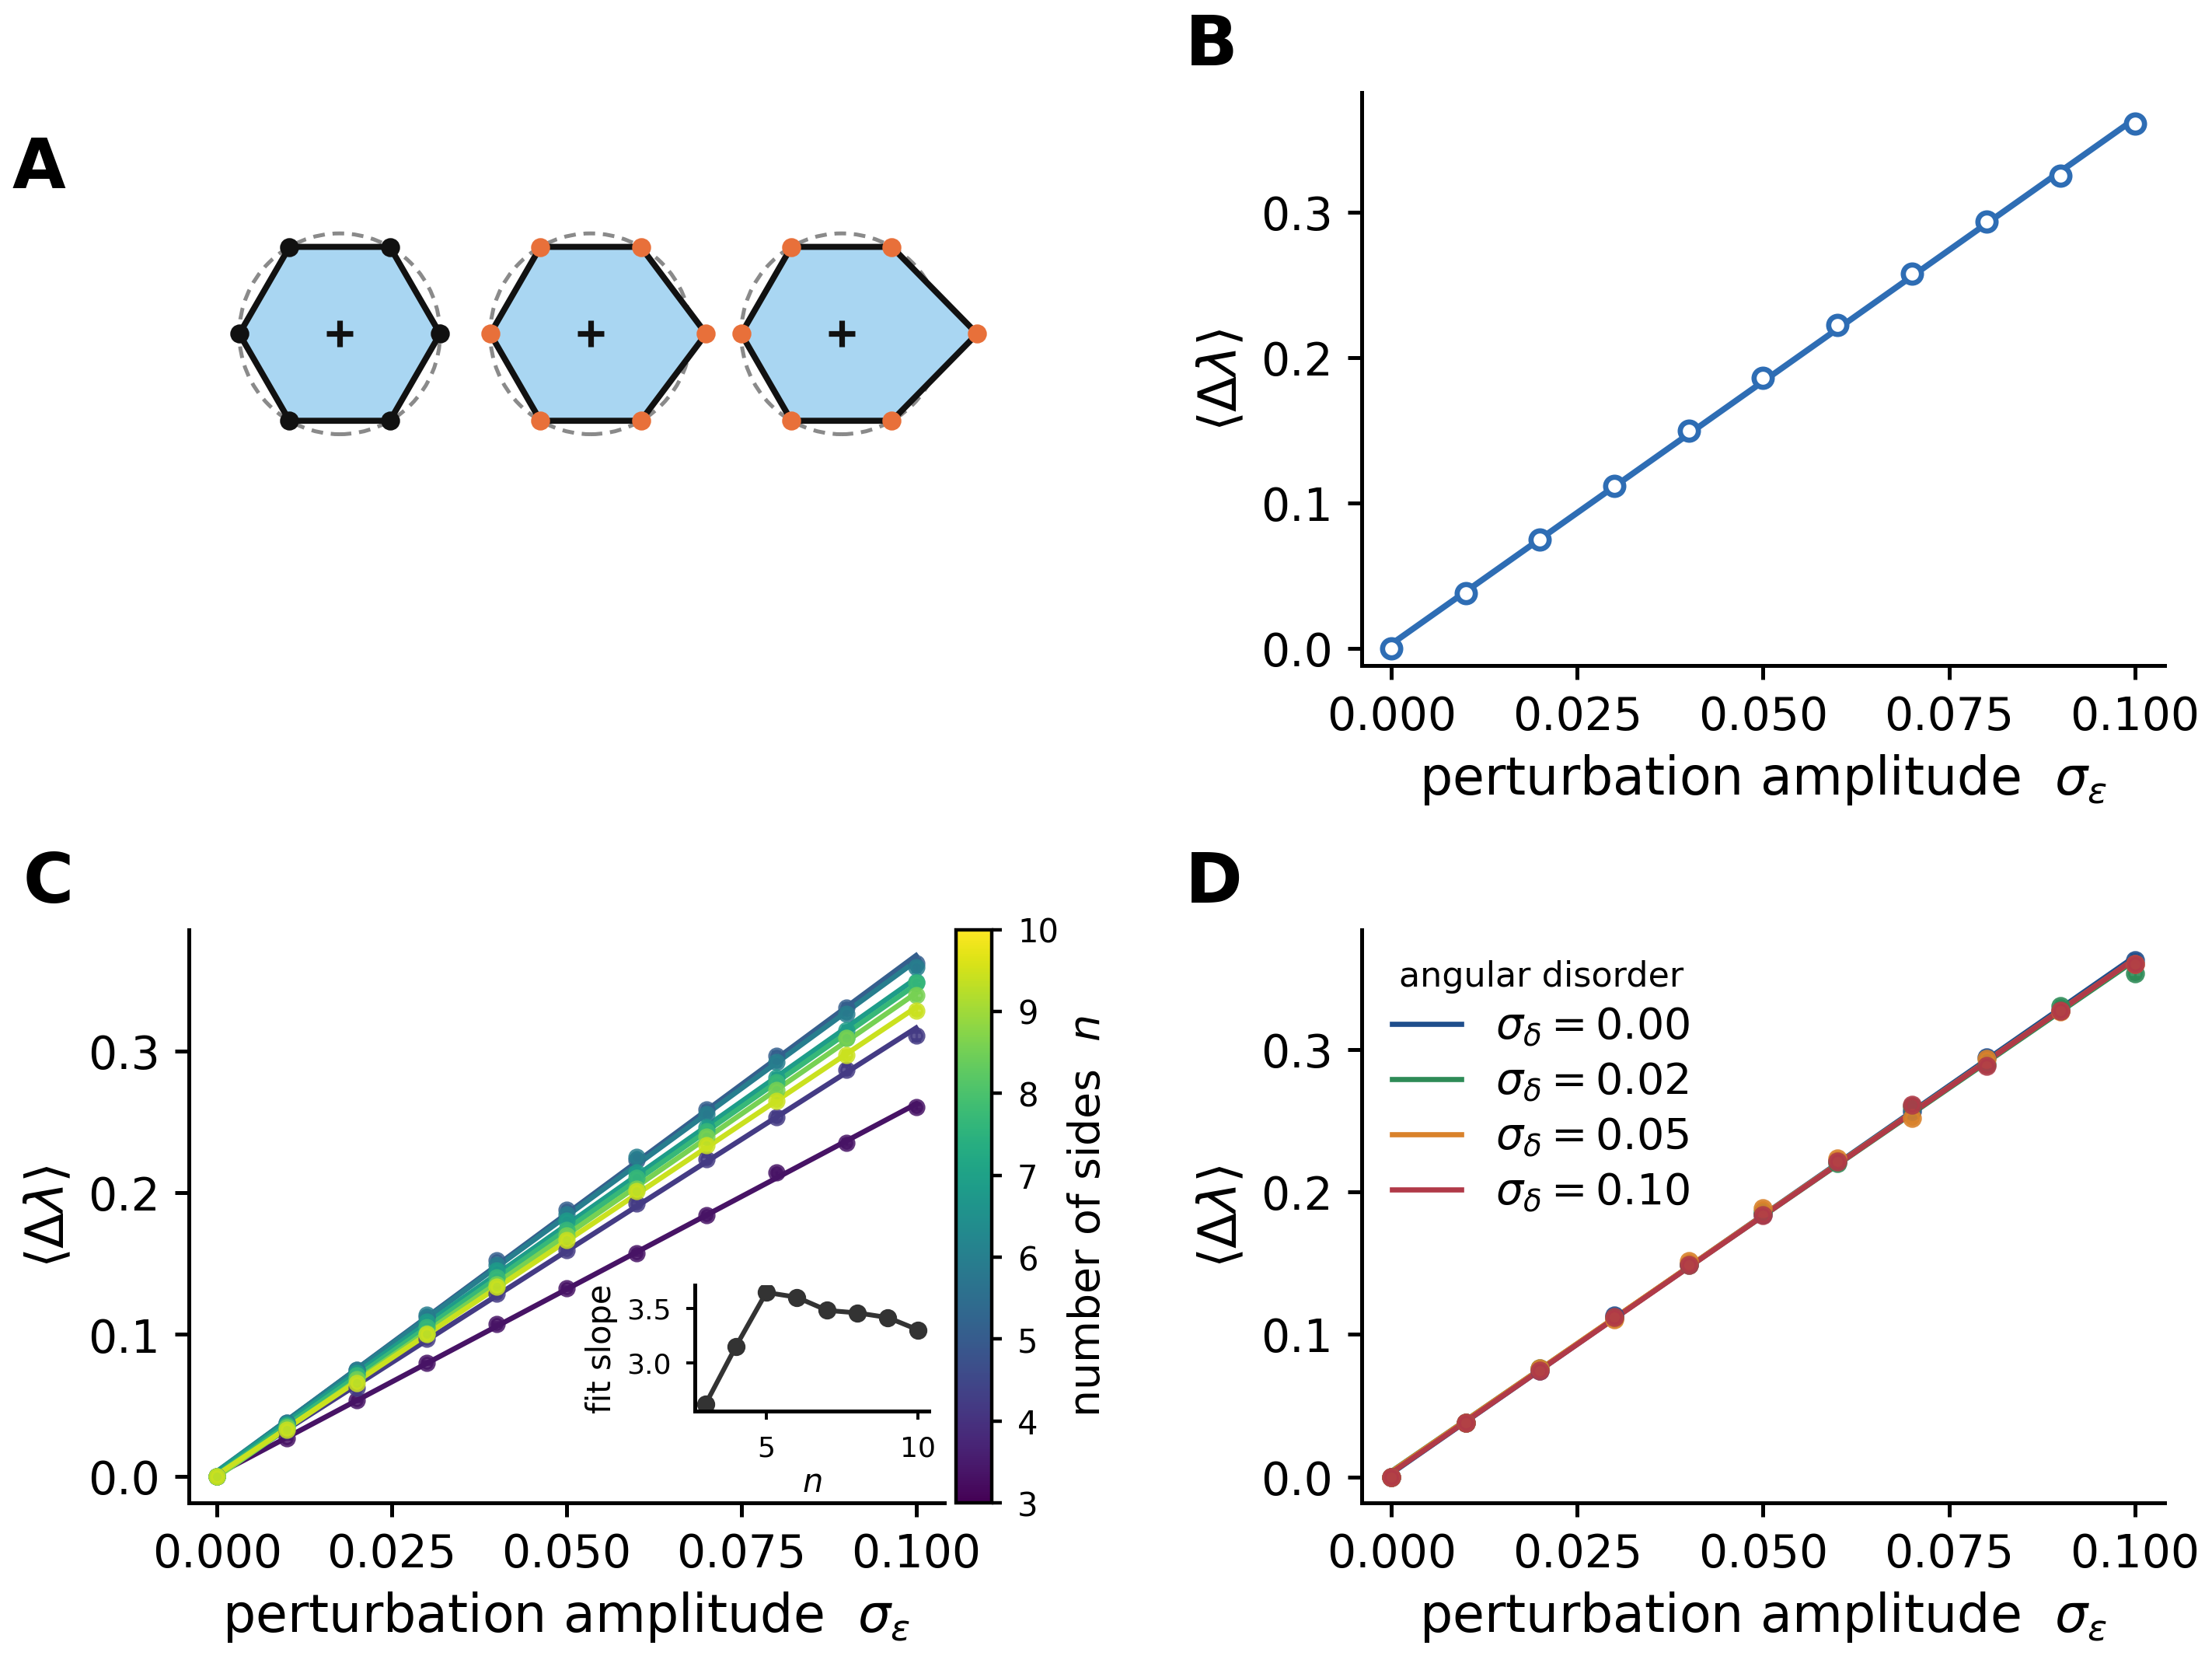

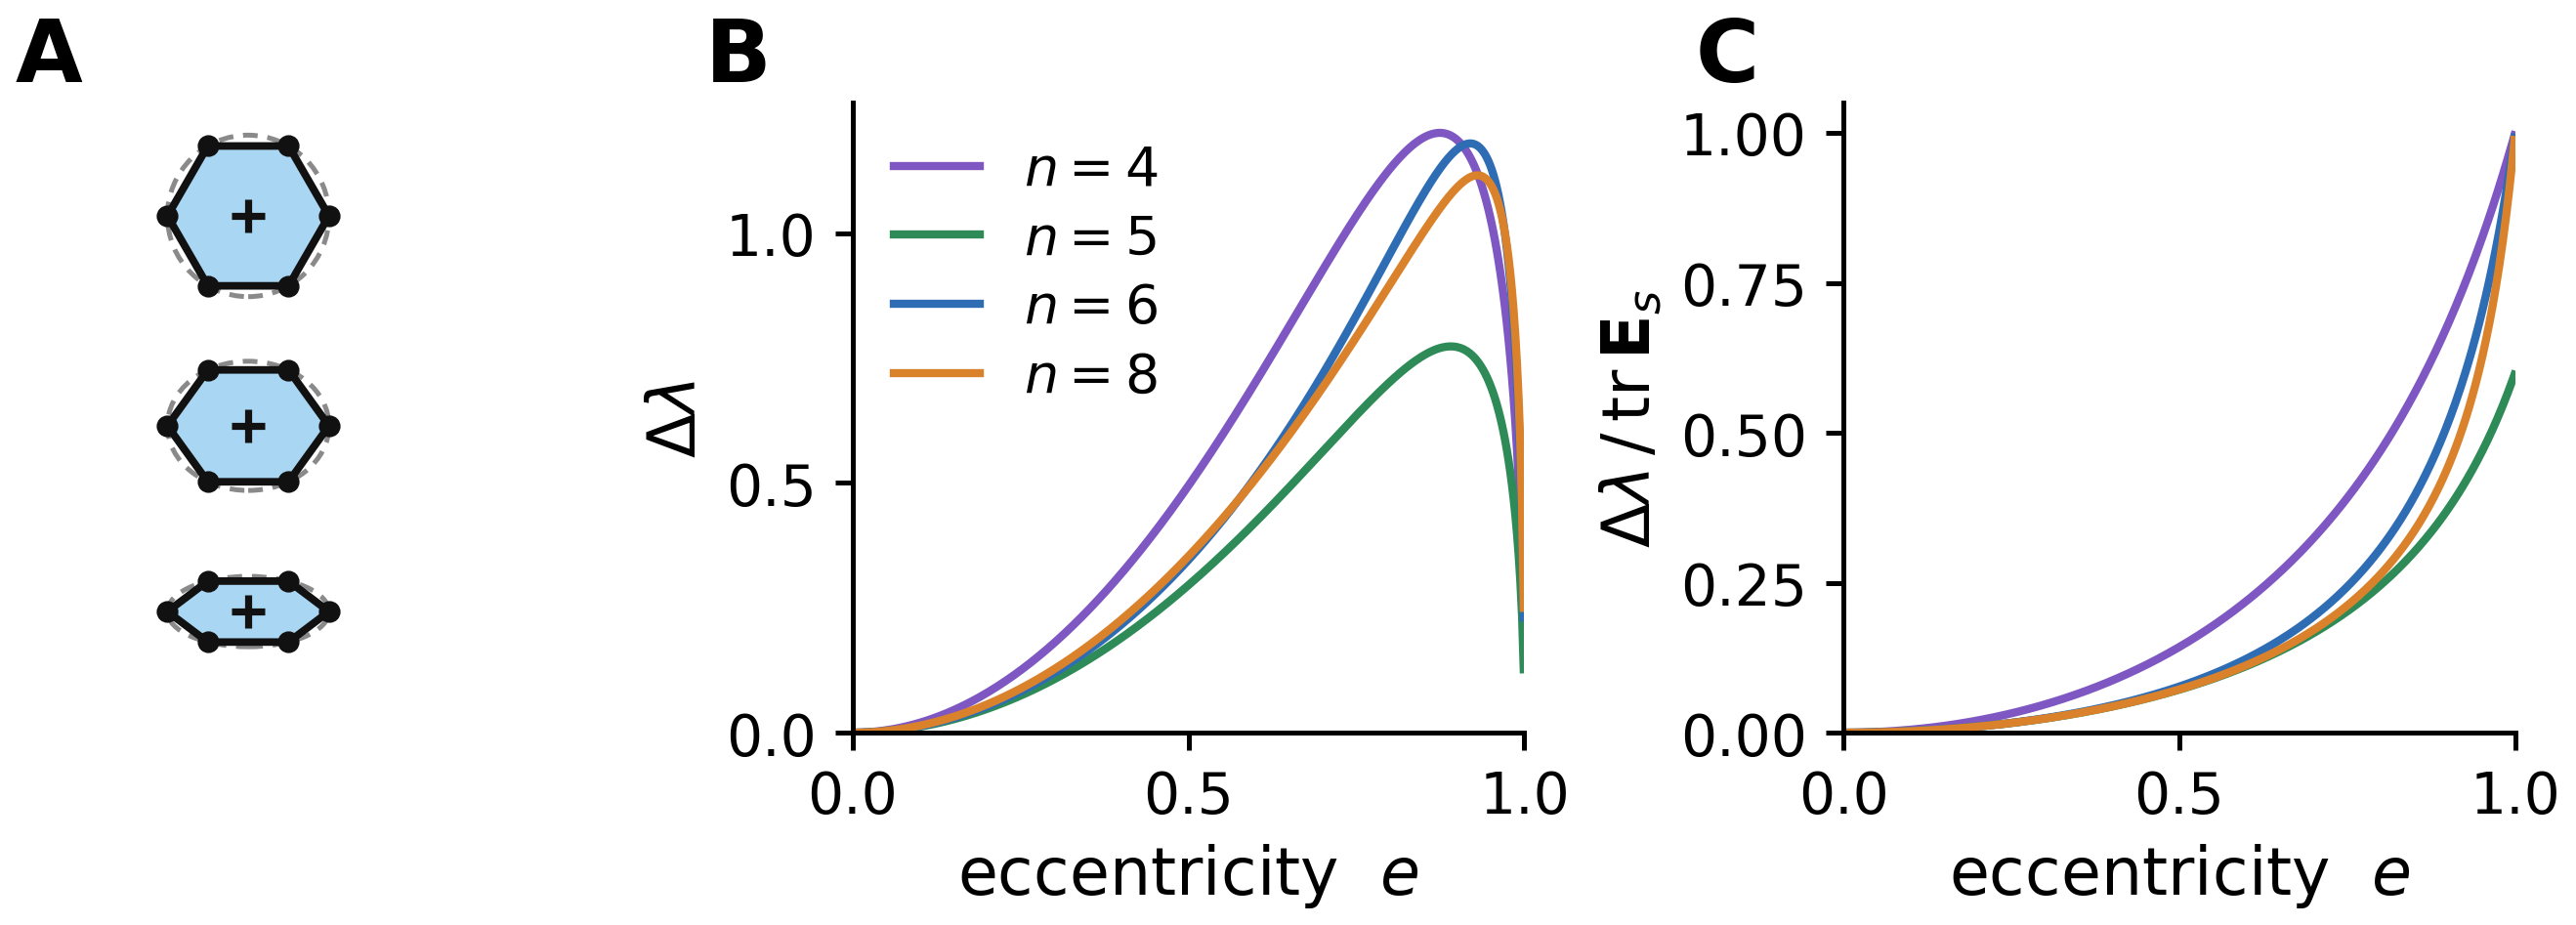

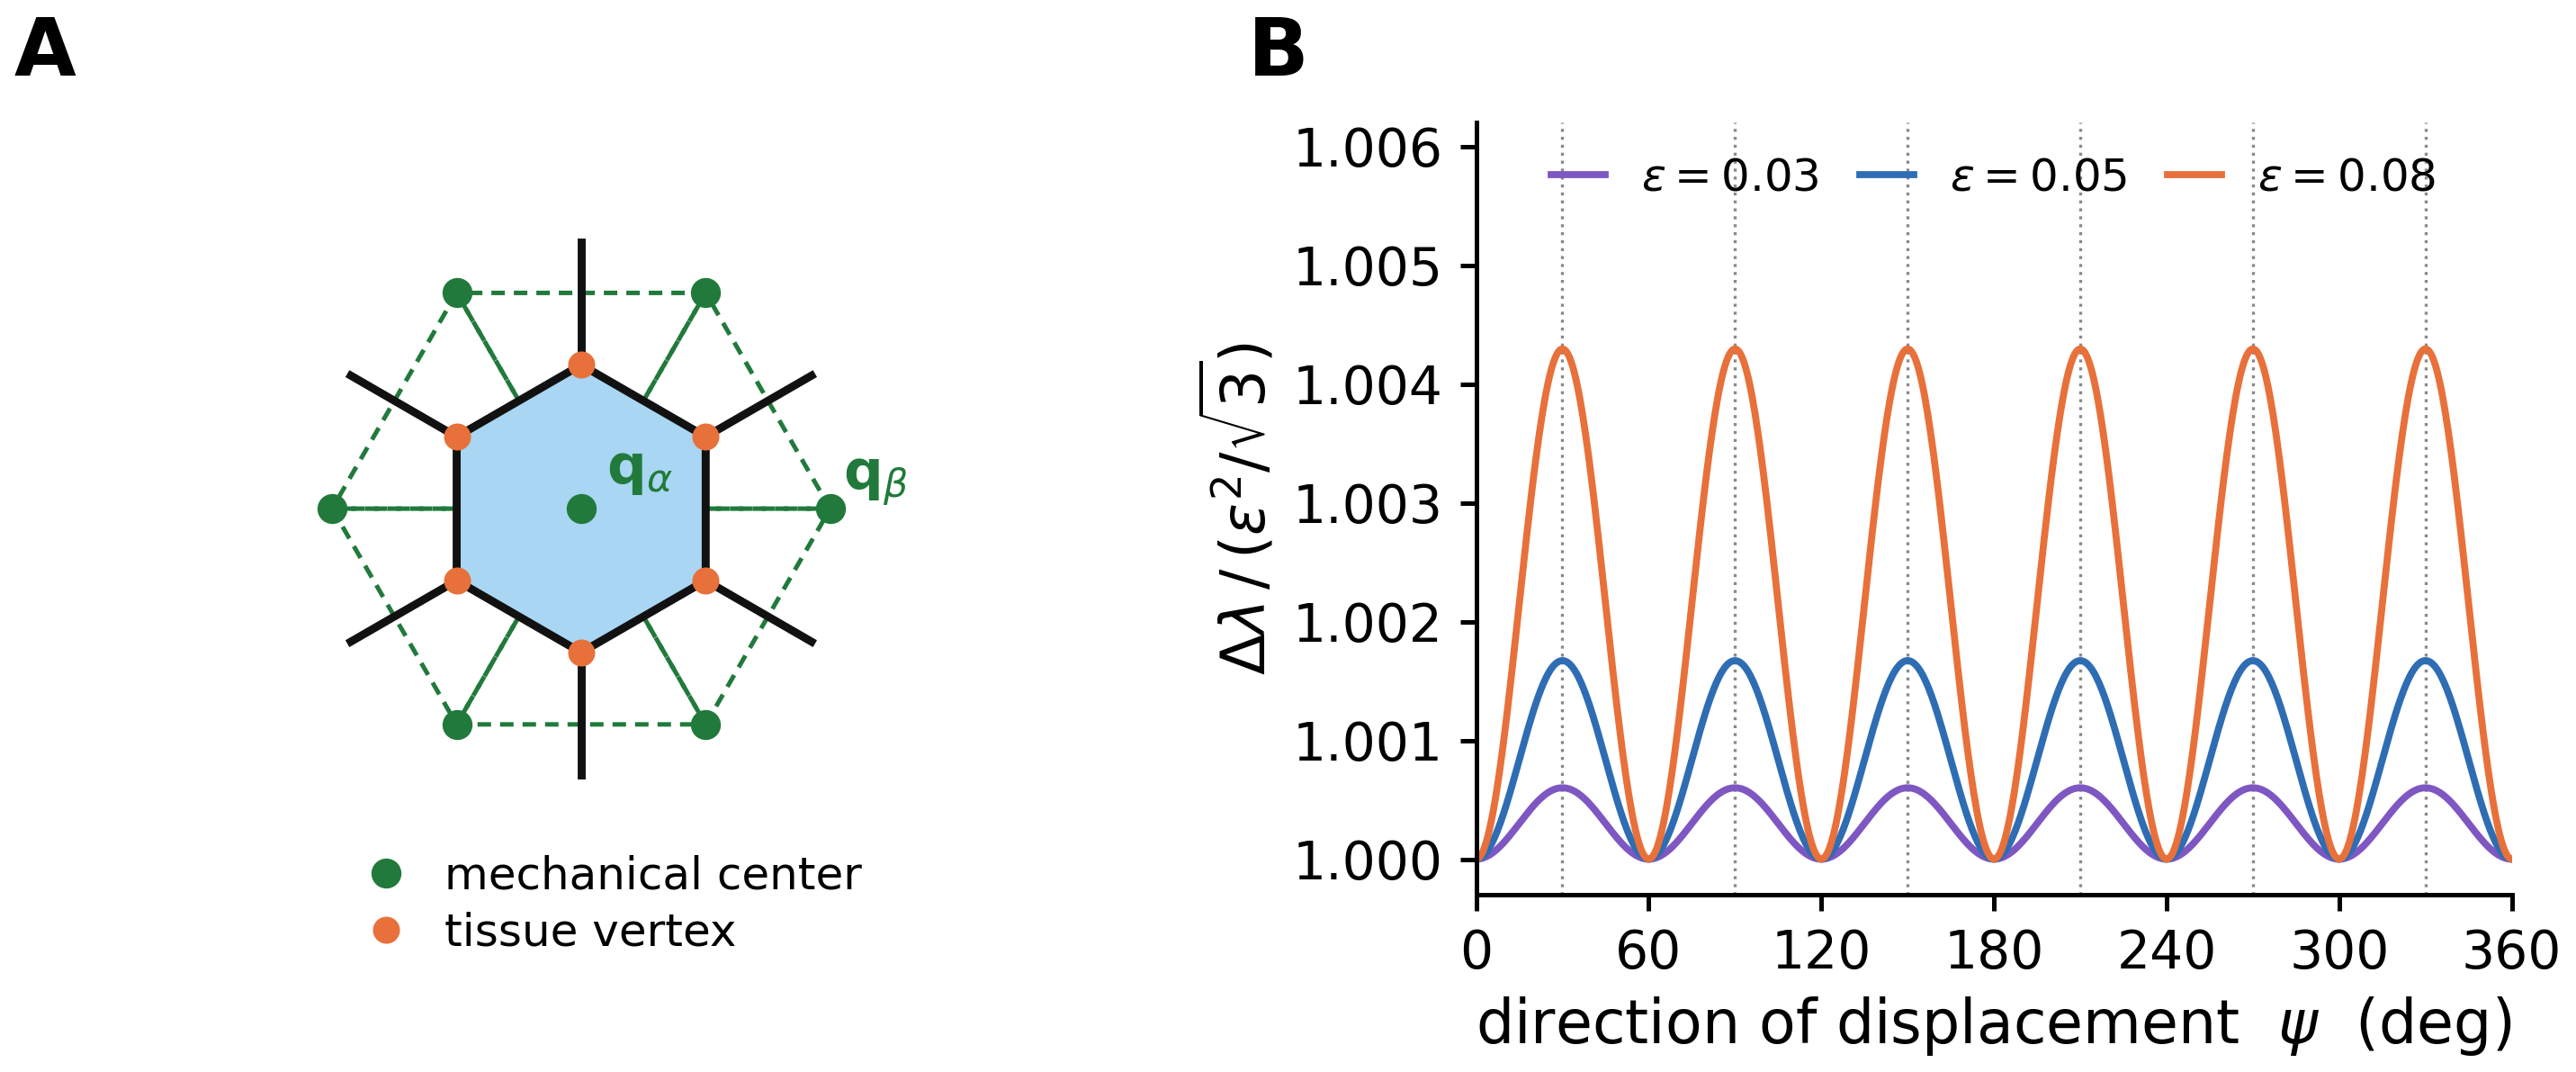

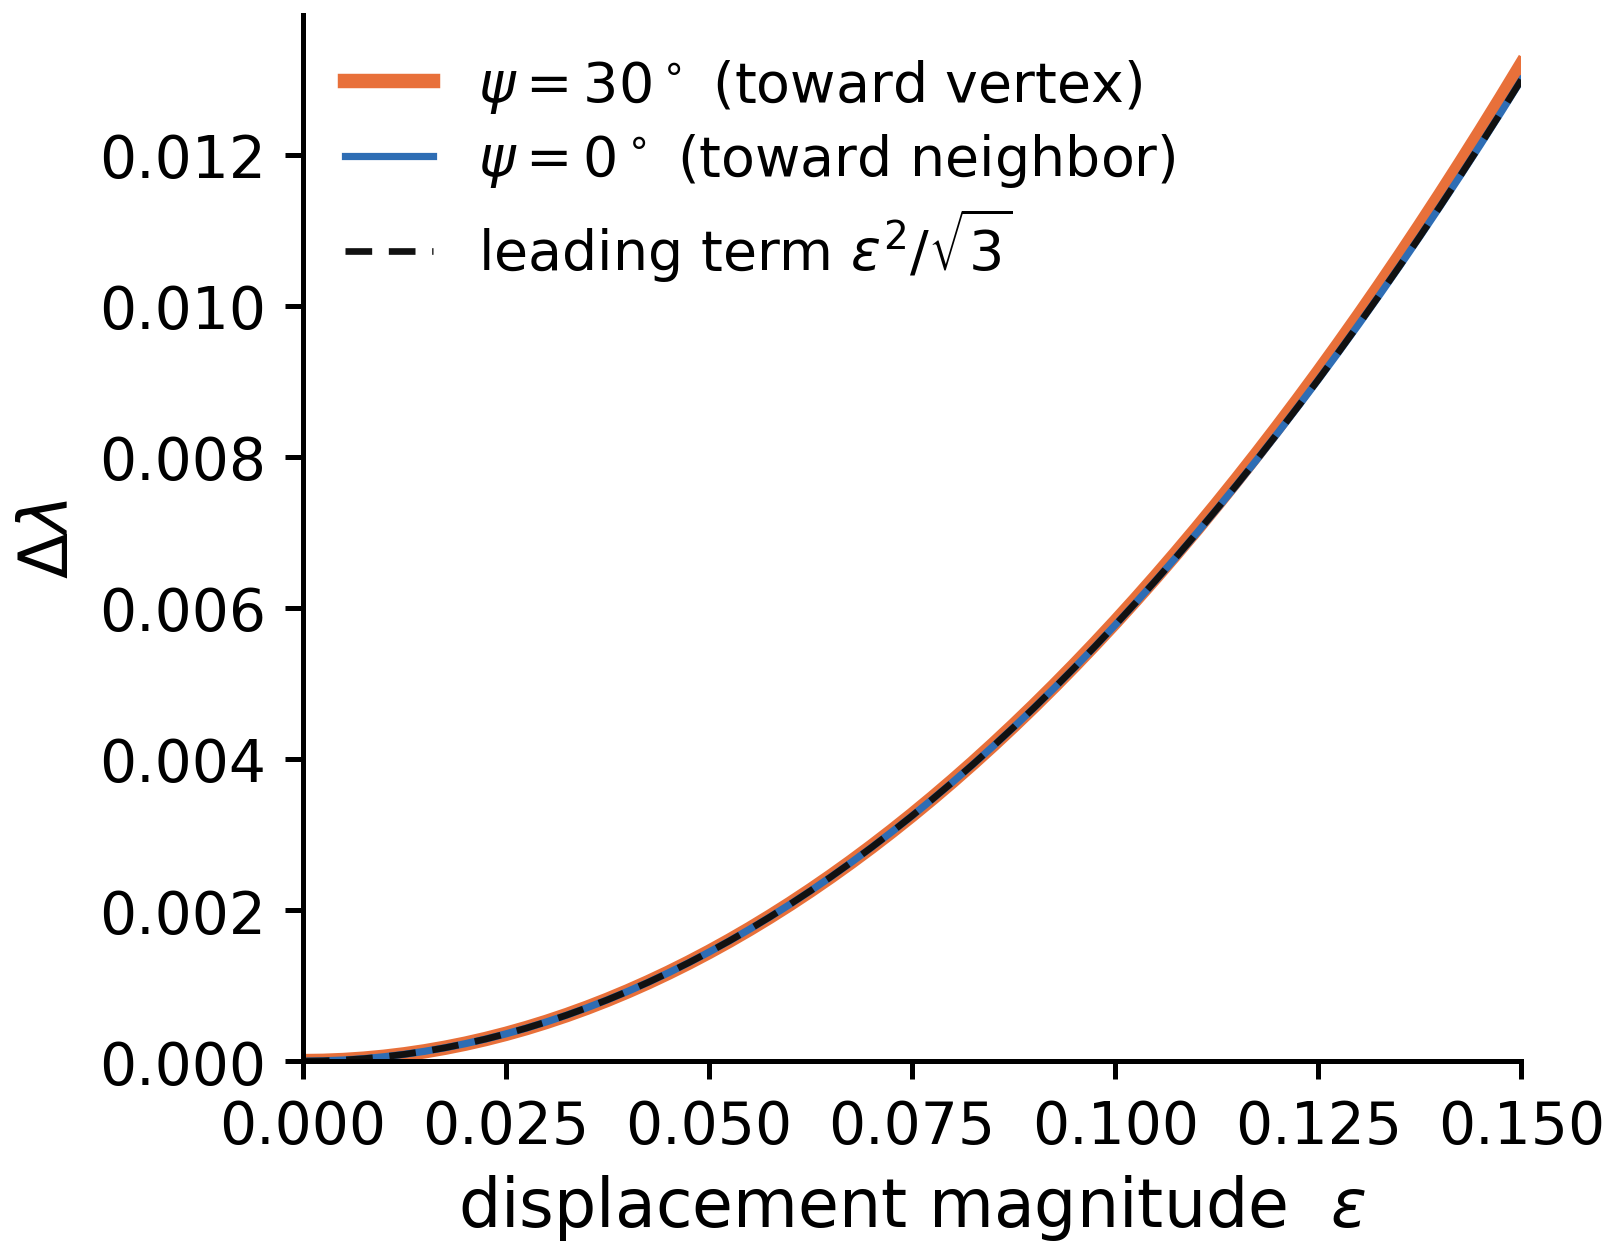

In [5]:
run_script('verify_package.py')
for name in ['figure5.png', 'figure6.png', 'figure7.png', 'figure7c.png']:
    show(name)


## 4. Tissue-scale results

The stored tissue array is checked by rebuilding its 200 fixed-seed Voronoi
realizations and independently assembling the cell tensors. Publication figures
are displayed without replacing their layouts. This path requires the supplied
`data/tissue_cells.npz`; full regeneration is available in Section 9.


{
  "maximum_absolute_errors": {
    "generator": 0.0,
    "W": 0.0,
    "area": 0.0,
    "tensor_assembly": 2.6645352591003757e-15,
    "junction_force": 1.2718718071287048e-14,
    "half_edge_allocation": 3.3306690738754696e-15,
    "raw_window": 0.0
  },
  "regenerated_realizations": 200,
  "checked_junctions": 204400,
  "checked_window_records": 2400,
  "cache_sha256": "ae3bb0afc41bbcaa09aa46cbb3b5960ebf99b472e498a1cb573d7c6d49452c26"
}
Original submitted asset: Fig7A.png
Original submitted asset: Fig7B.png
Original submitted asset: Fig7C.png
Original submitted asset: figure8b.png


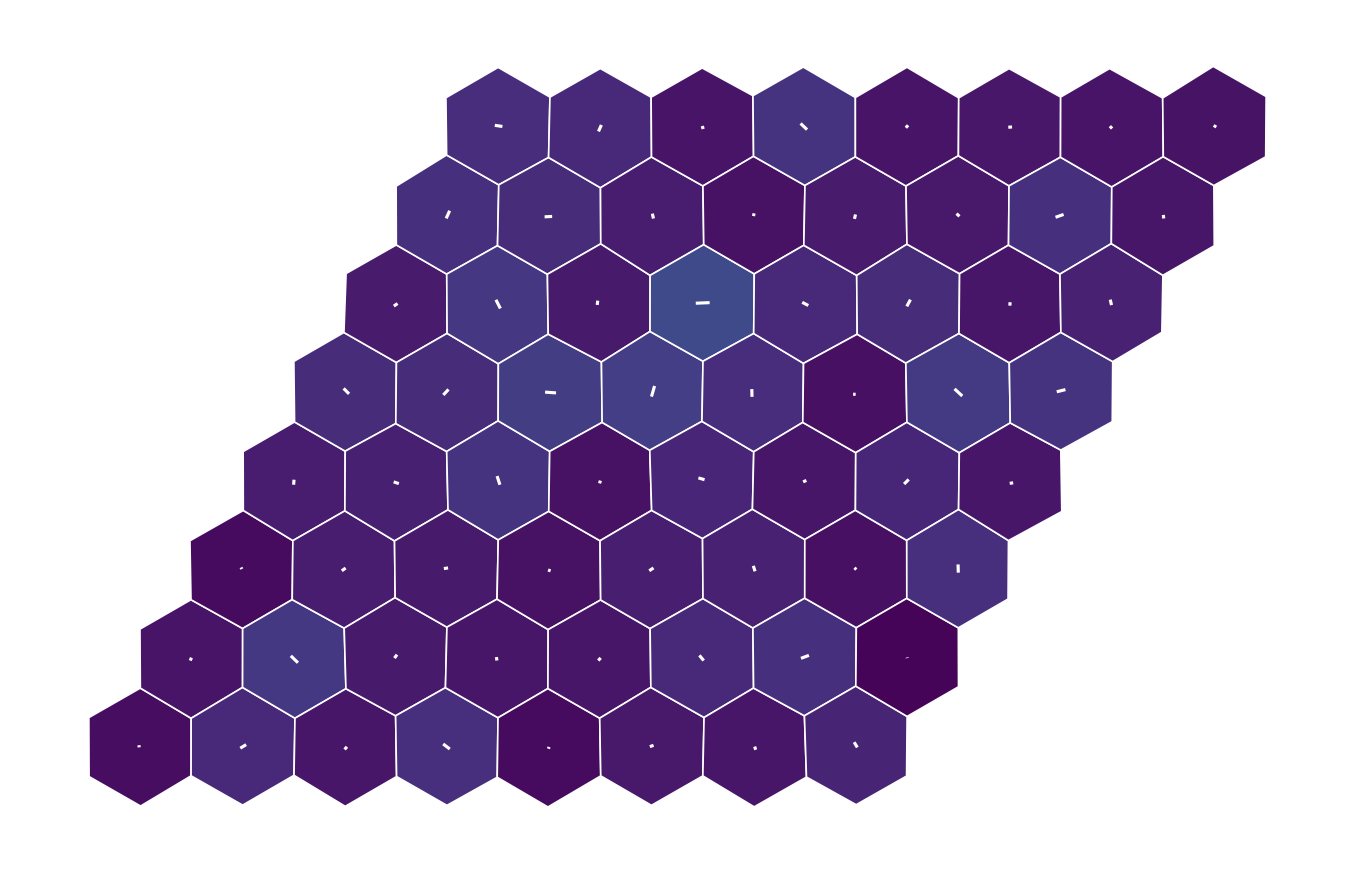

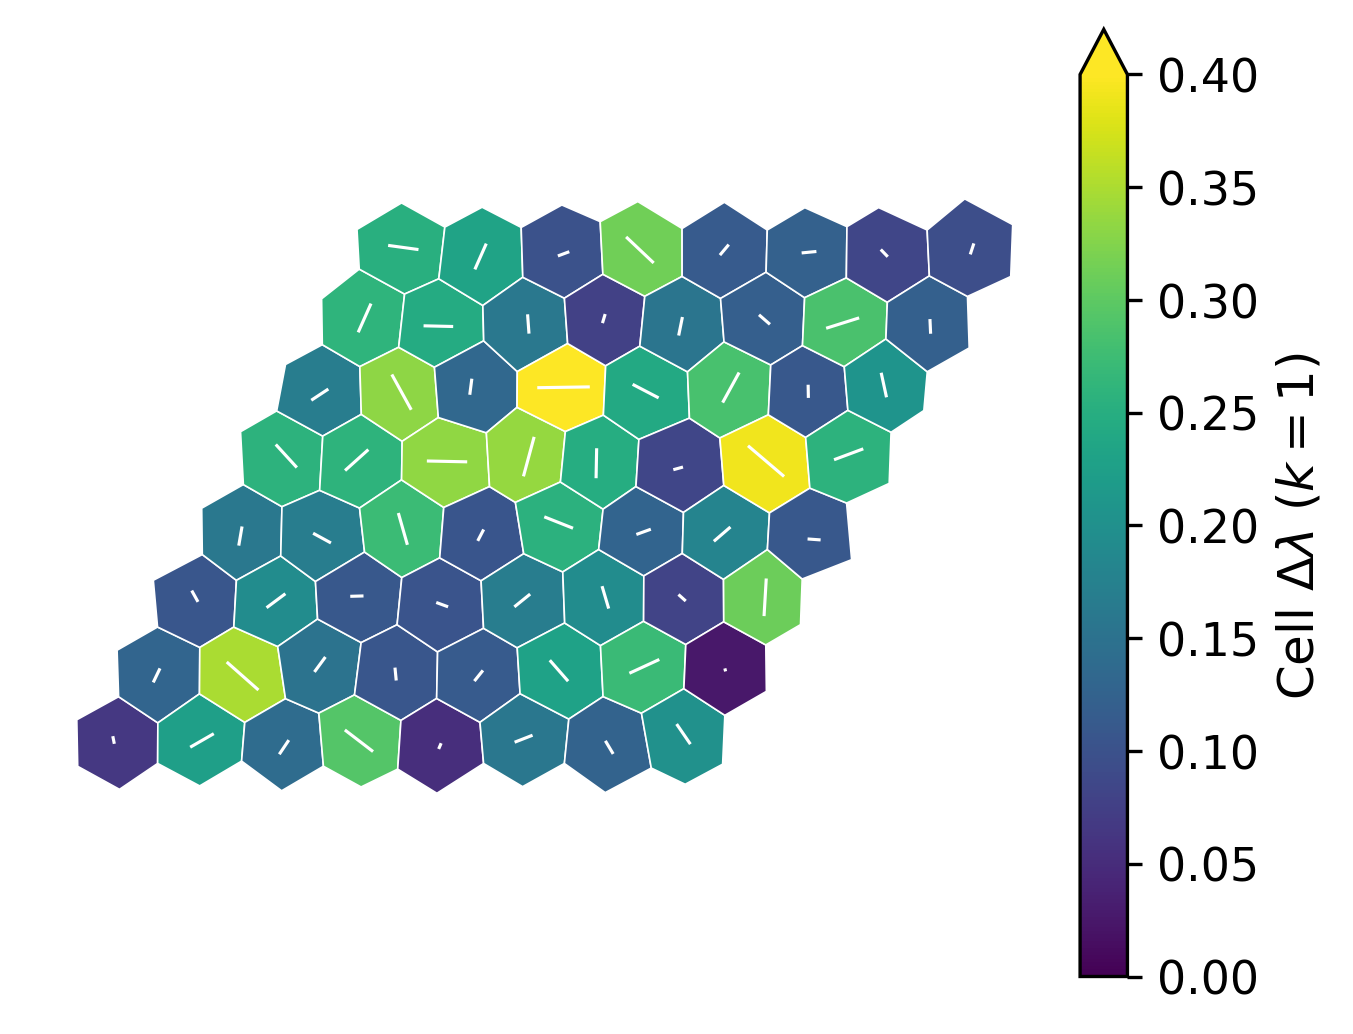

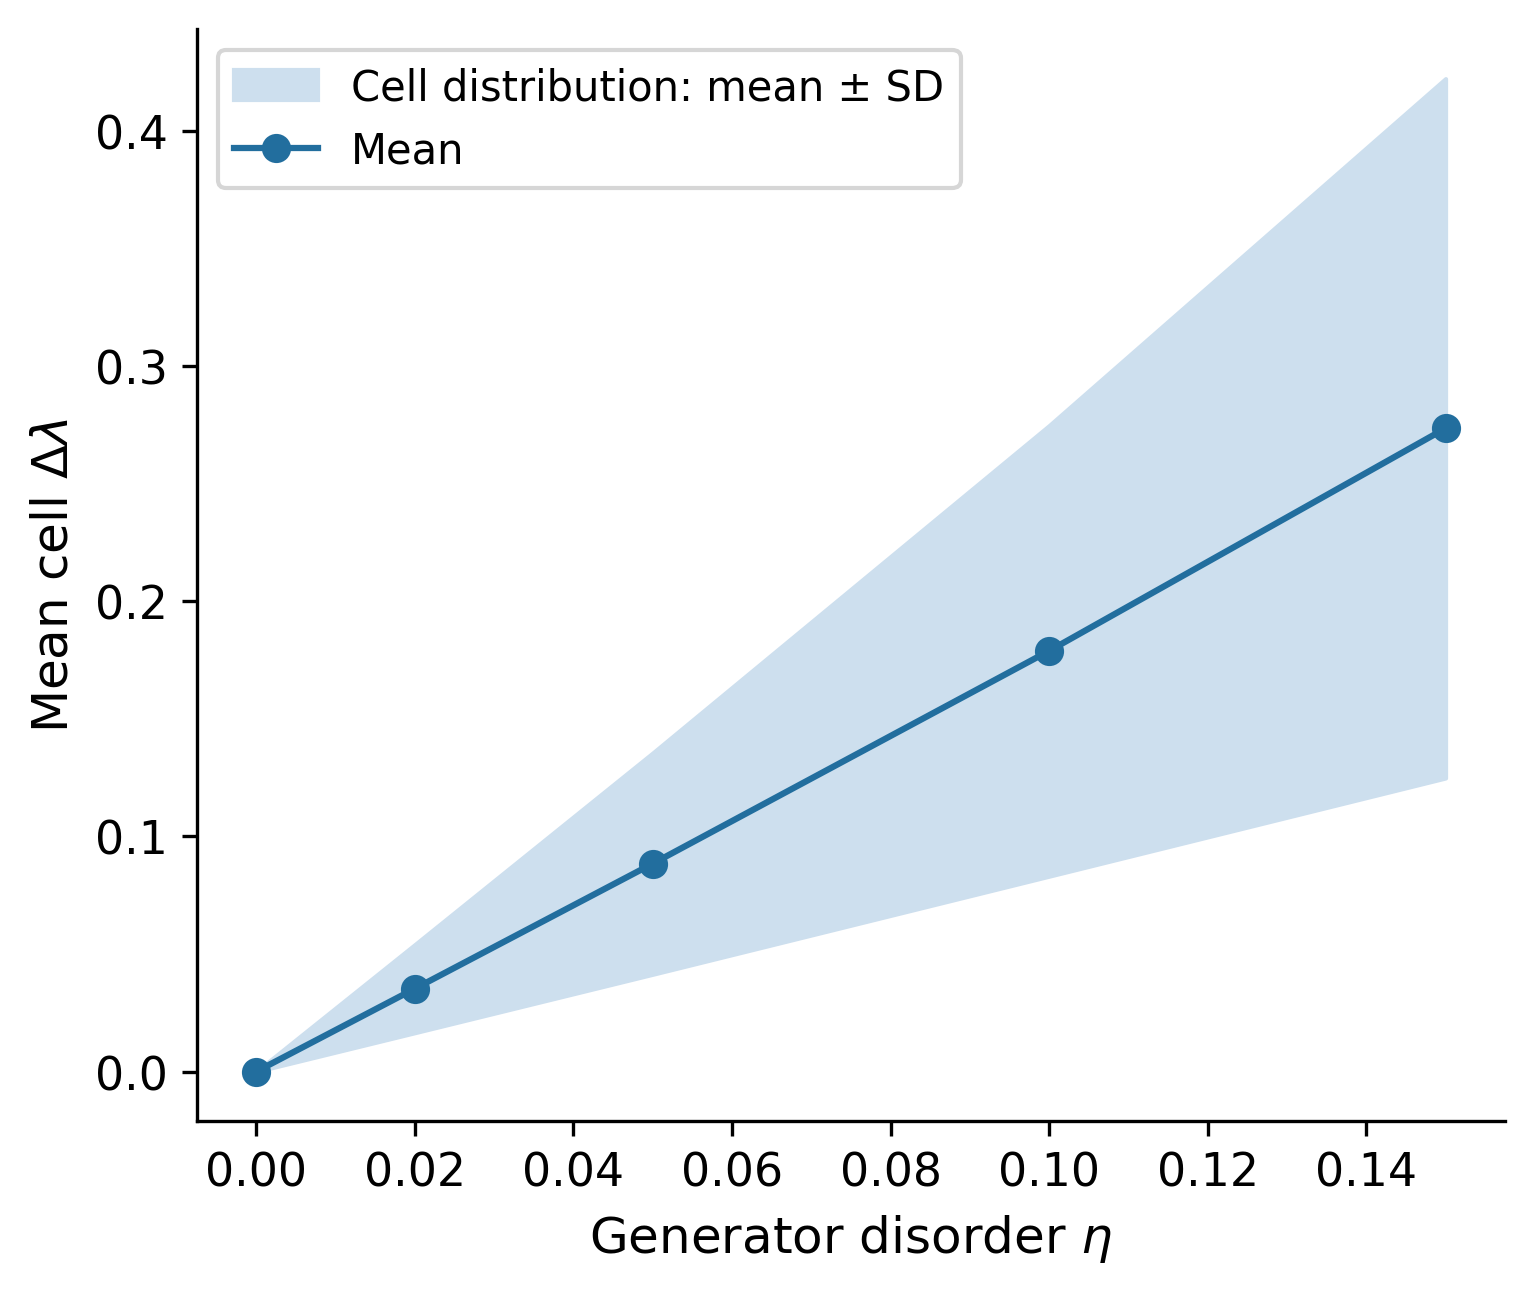

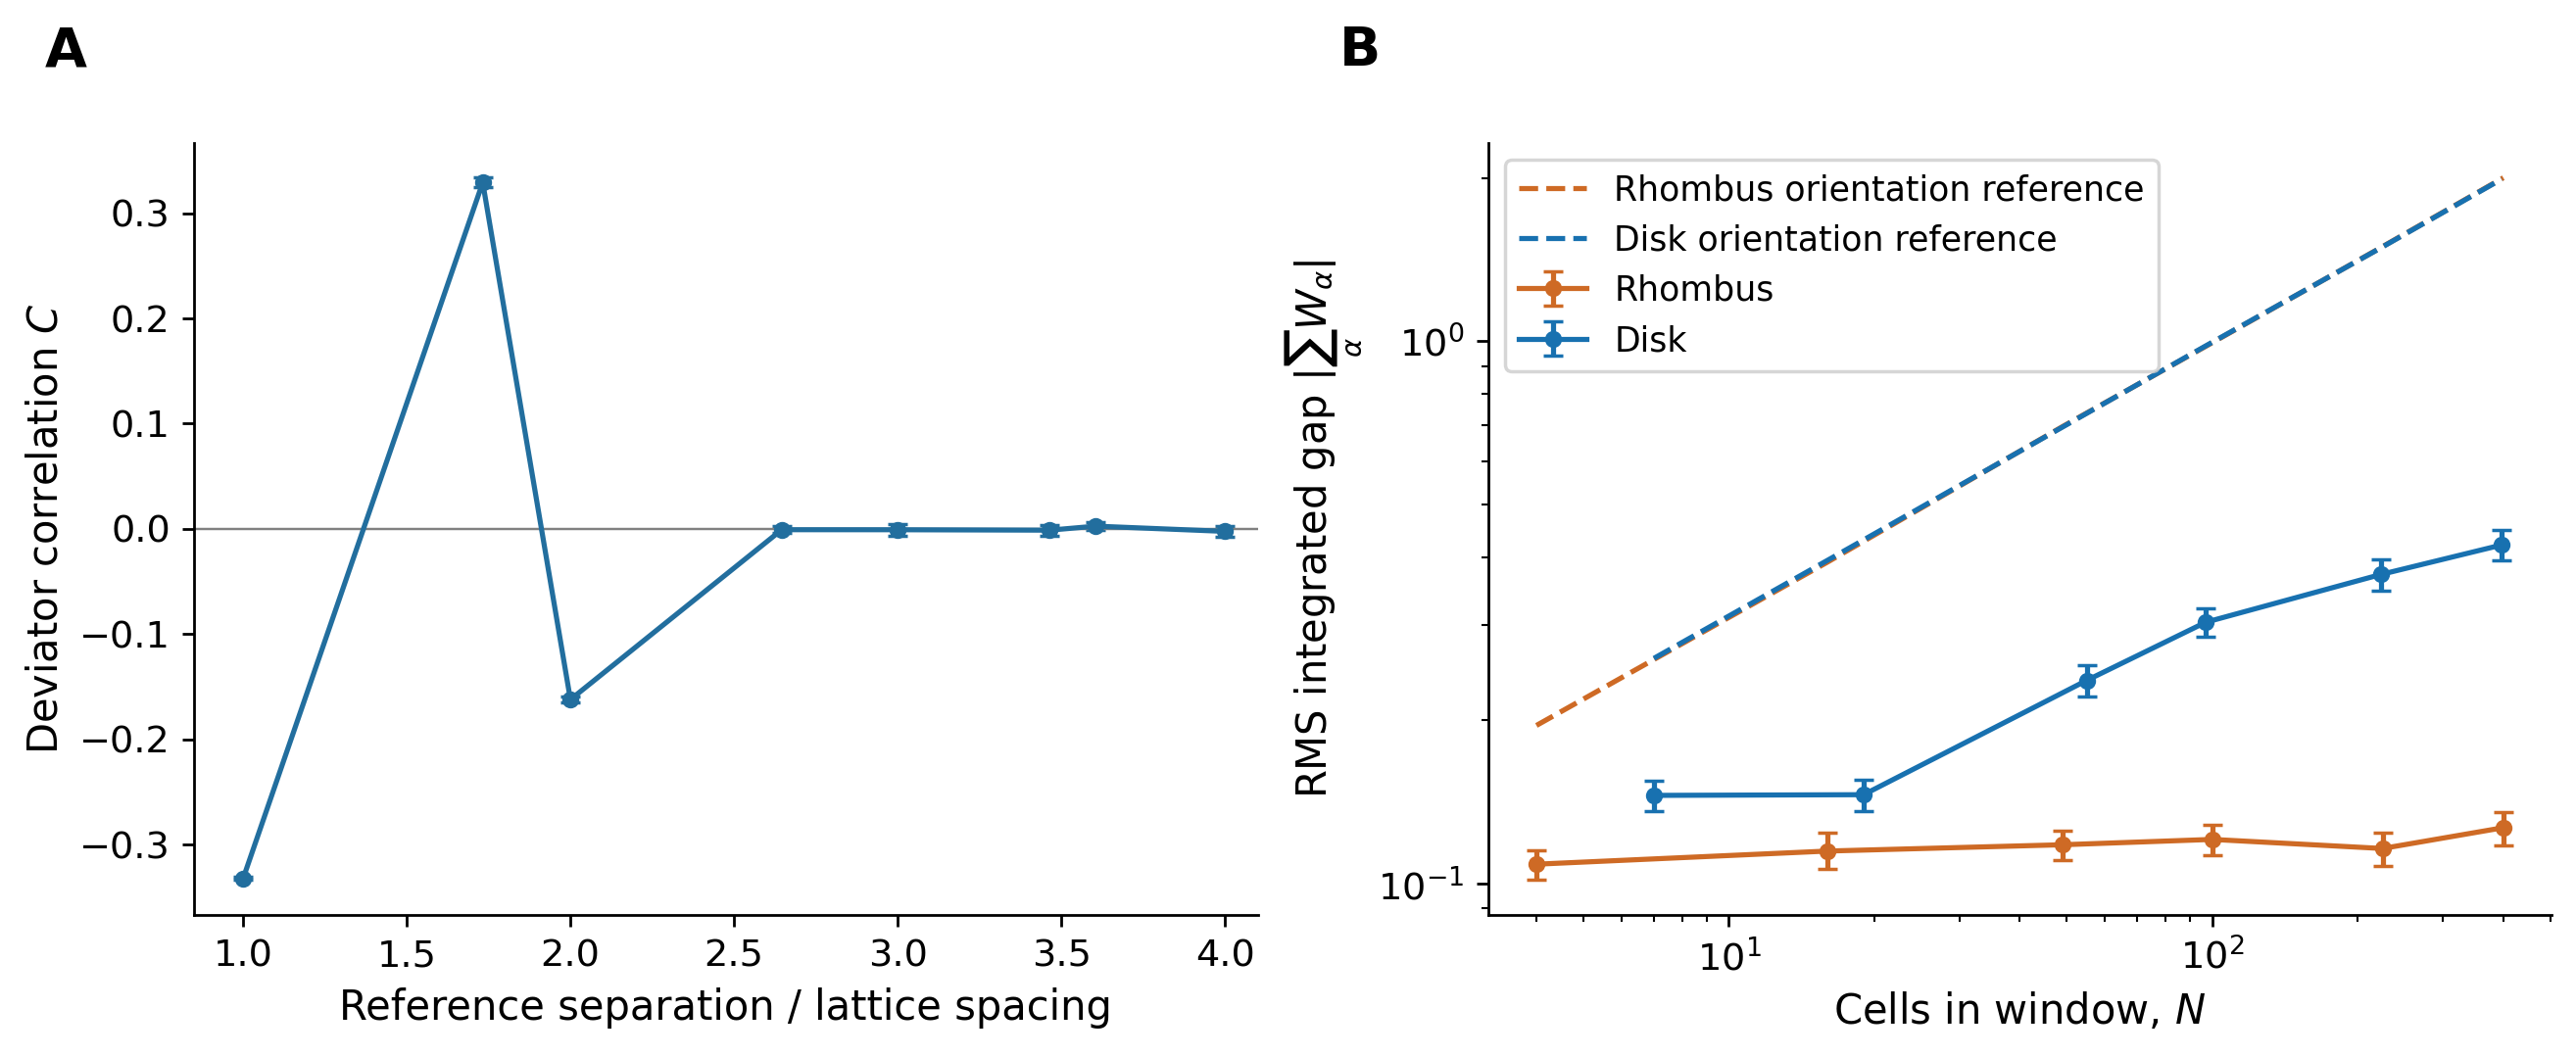

In [6]:
import json
import numpy as np
from run_tissue import verify_window_data
metadata = json.loads((ROOT/'data/tissue_metadata.json').read_text())
with np.load(ROOT/'data/tissue_cells.npz') as archive:
    tissue_check = verify_window_data(archive, metadata)
print(json.dumps(tissue_check, indent=2))
for name in ['Fig7A.png', 'Fig7B.png', 'Fig7C.png', 'figure8b.png']:
    show(name, 720)


## 5. The exact regional boundary identity

The boundary and cell assemblies are evaluated independently for each retained
window. The script also regenerates the regular-generator squeeze null control
and compatible affine physical-loading comparison.


{
  "boundary_windows": 2400,
  "boundary_realizations": 200,
  "max_complex_boundary_identity_error": 1.718738241967731e-13,
  "maximum_bound_violation": 0.0,
  "maximum_squeezed_Bravais_cell_gap": 8.881784197001252e-15,
  "maximum_affine_tensor_error": 3.979039320256561e-13,
  "squeeze_amplitudes": 41,
  "localized_controls": 80,
  "maximum_localized_regional_gap": 1.3642883633997482e-12,
  "maximum_localized_identity_error": 1.6428448357939493e-12,
  "localized_eta_point2_mean_local_gap": 0.10061822440242947,
  "affine_force_convention": "F f, determinant(F)=1; ordinary Voronoi is not recomputed",
  "provenance": "Retained tissue cache regenerated from its recorded seed; boundary assembled independently from exterior ridges"
}

Reproduction diagnostic: regional_boundary.png


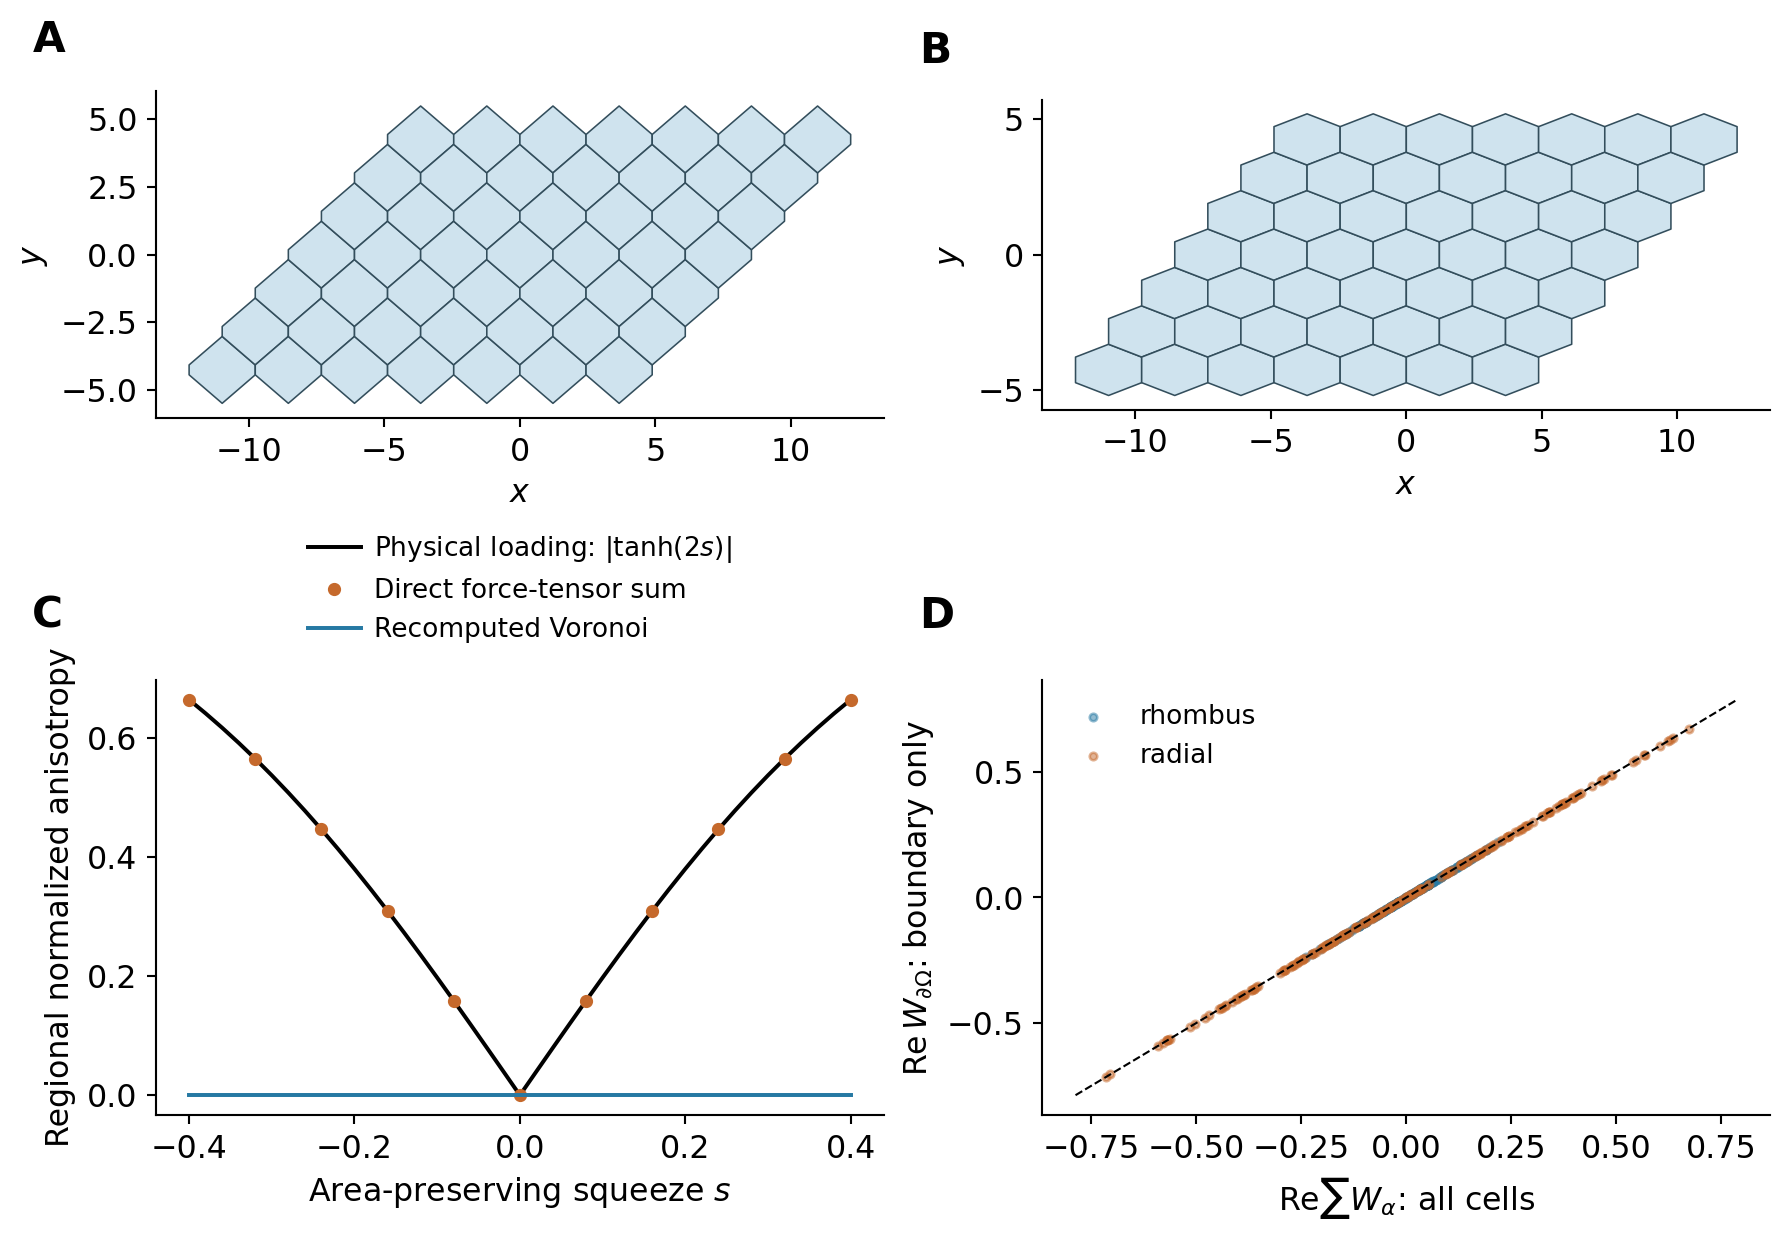

In [7]:
run_script('run_boundary_identity.py')
show('regional_boundary.png', generated=True)

## 6. Reference-label window families and fixed-geometry controls

* `run_boundary_scaling.py`: three masks defined in nonorthogonal lattice labels.
  A label disk is not a physical disk; rotating a label box also changes physical
  shape. The fitted slopes describe the tested window families, not a universal
  commensurability or scaling law.
* `run_driven_strain.py`: squeeze the generators and rebuild ordinary Voronoi cells.
* `run_polarized_tension.py`: impose orientation-dependent tension coefficients at
  **fixed geometry without re-equilibration**. It is a prescribed-force diagnostic, with limitations discussed in the SI.

The loading observation region is **18×18 = 324 cells**. Both original and
mean-subtracted amplitude-weighted orientation statistics are saved. The original
statistic uses a product-of-magnitudes denominator and is distinct from the earlier
RMS-normalized shell correlation. It is not a validated classifier.

Every main realization and nested-window value is saved to CSV. Bootstrap fits
resample whole realizations jointly across masks; their intervals quantify Monte
Carlo variability within the finite protocol.

In [8]:
run_script('run_boundary_scaling.py')

label_box: empirical slope vs N=0.059428; vs boundary count=0.107446
label_disk: empirical slope vs N=0.306046; vs boundary count=0.552051
label_rotated_box: empirical slope vs N=0.264443; vs boundary count=0.461164



In [9]:
run_script('run_driven_strain.py')

Rebuilt Voronoi control: 324 cells; 40 paired realizations per amplitude.
eps=0.00: gap=0.13257946; C_amp=-0.410824; centered=-0.410819
eps=0.01: gap=0.13204286; C_amp=-0.411163; centered=-0.411160
eps=0.02: gap=0.13183020; C_amp=-0.412057; centered=-0.412055
eps=0.05: gap=0.13315152; C_amp=-0.417891; centered=-0.417892
eps=0.10: gap=0.14178666; C_amp=-0.435526; centered=-0.435530
eps=0.20: gap=0.18059516; C_amp=-0.474412; centered=-0.474415



In [10]:
run_script('run_polarized_tension.py')

Fixed-geometry diagnostic: 324 cells, 40 realizations/amplitude; tensions NOT re-equilibrated.
Saved original uncentered amplitude-weighted orientation statistic and mean-subtracted controls.
beta=0.00: gap=0.14705392; C_amp=-0.410023; centered=-0.410026
beta=0.02: gap=22.44218050; C_amp=0.131224; centered=-0.409443
beta=0.05: gap=56.11058369; C_amp=0.792694; centered=-0.406319
beta=0.10: gap=112.22497418; C_amp=0.953760; centered=-0.395416
beta=0.20: gap=224.45389958; C_amp=0.990217; centered=-0.356348
beta=0.40: gap=448.91182258; C_amp=0.997915; centered=-0.247857



{
  "boundary_scaling_realizations.csv": [
    {
      "group": "label_box",
      "N_min": 36.0,
      "N_max": 400.0,
      "realizations": 60,
      "bootstrap_draws": 2000,
      "bootstrap_seed": 2026091500,
      "interpretation": "paired-realization bootstrap of descriptive finite-range log-log fit; not asymptotic uncertainty",
      "N": {
        "slope": 0.0594277285841573,
        "q025": 0.012133766596758177,
        "q975": 0.10643182753066602
      },
      "boundary_cells": {
        "slope": 0.10744565312963977,
        "q025": 0.022200373562116803,
        "q975": 0.19275910923446338
      }
    },
    {
      "group": "label_disk",
      "N_min": 32.0,
      "N_max": 332.0,
      "realizations": 60,
      "bootstrap_draws": 2000,
      "bootstrap_seed": 2026091501,
      "interpretation": "paired-realization bootstrap of descriptive finite-range log-log fit; not asymptotic uncertainty",
      "N": {
        "slope": 0.3060464841238433,
        "q025": 0.23295407752019

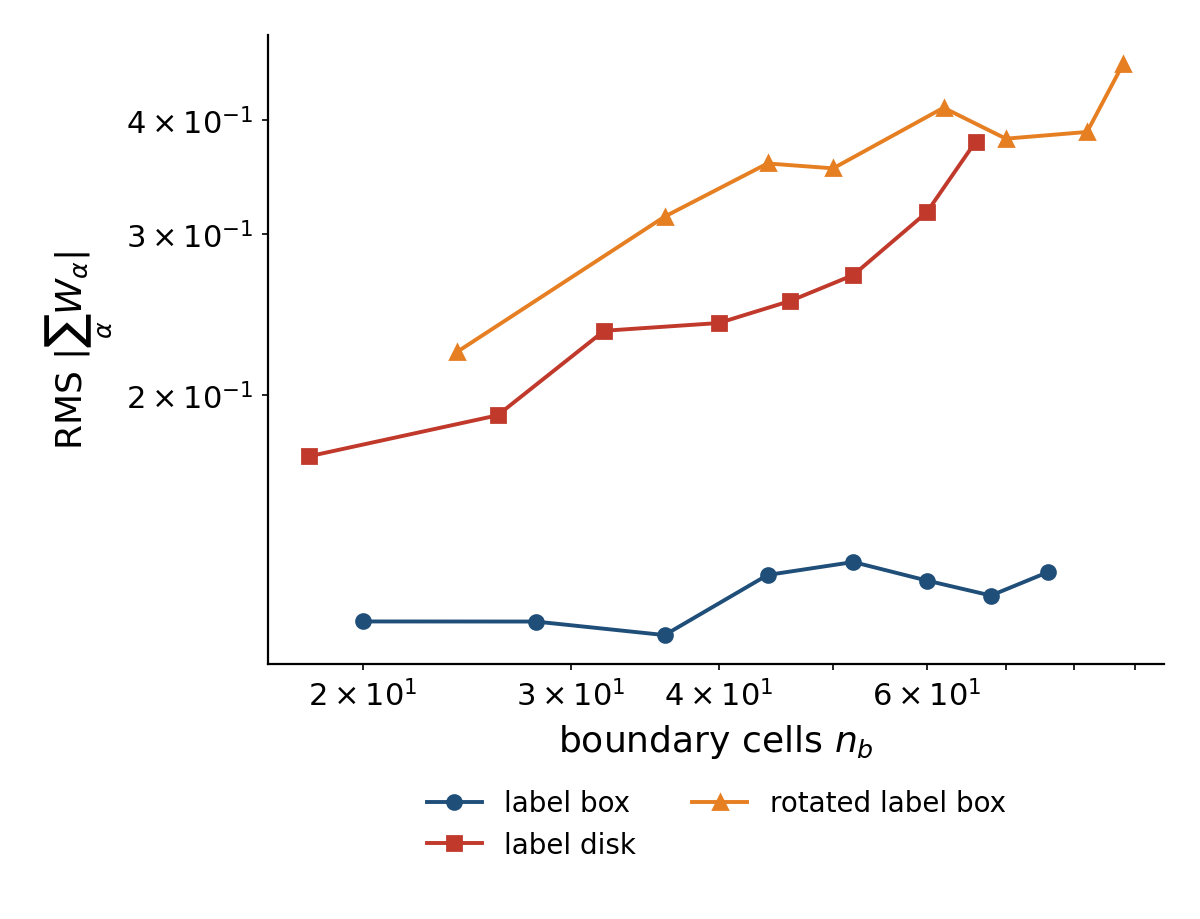

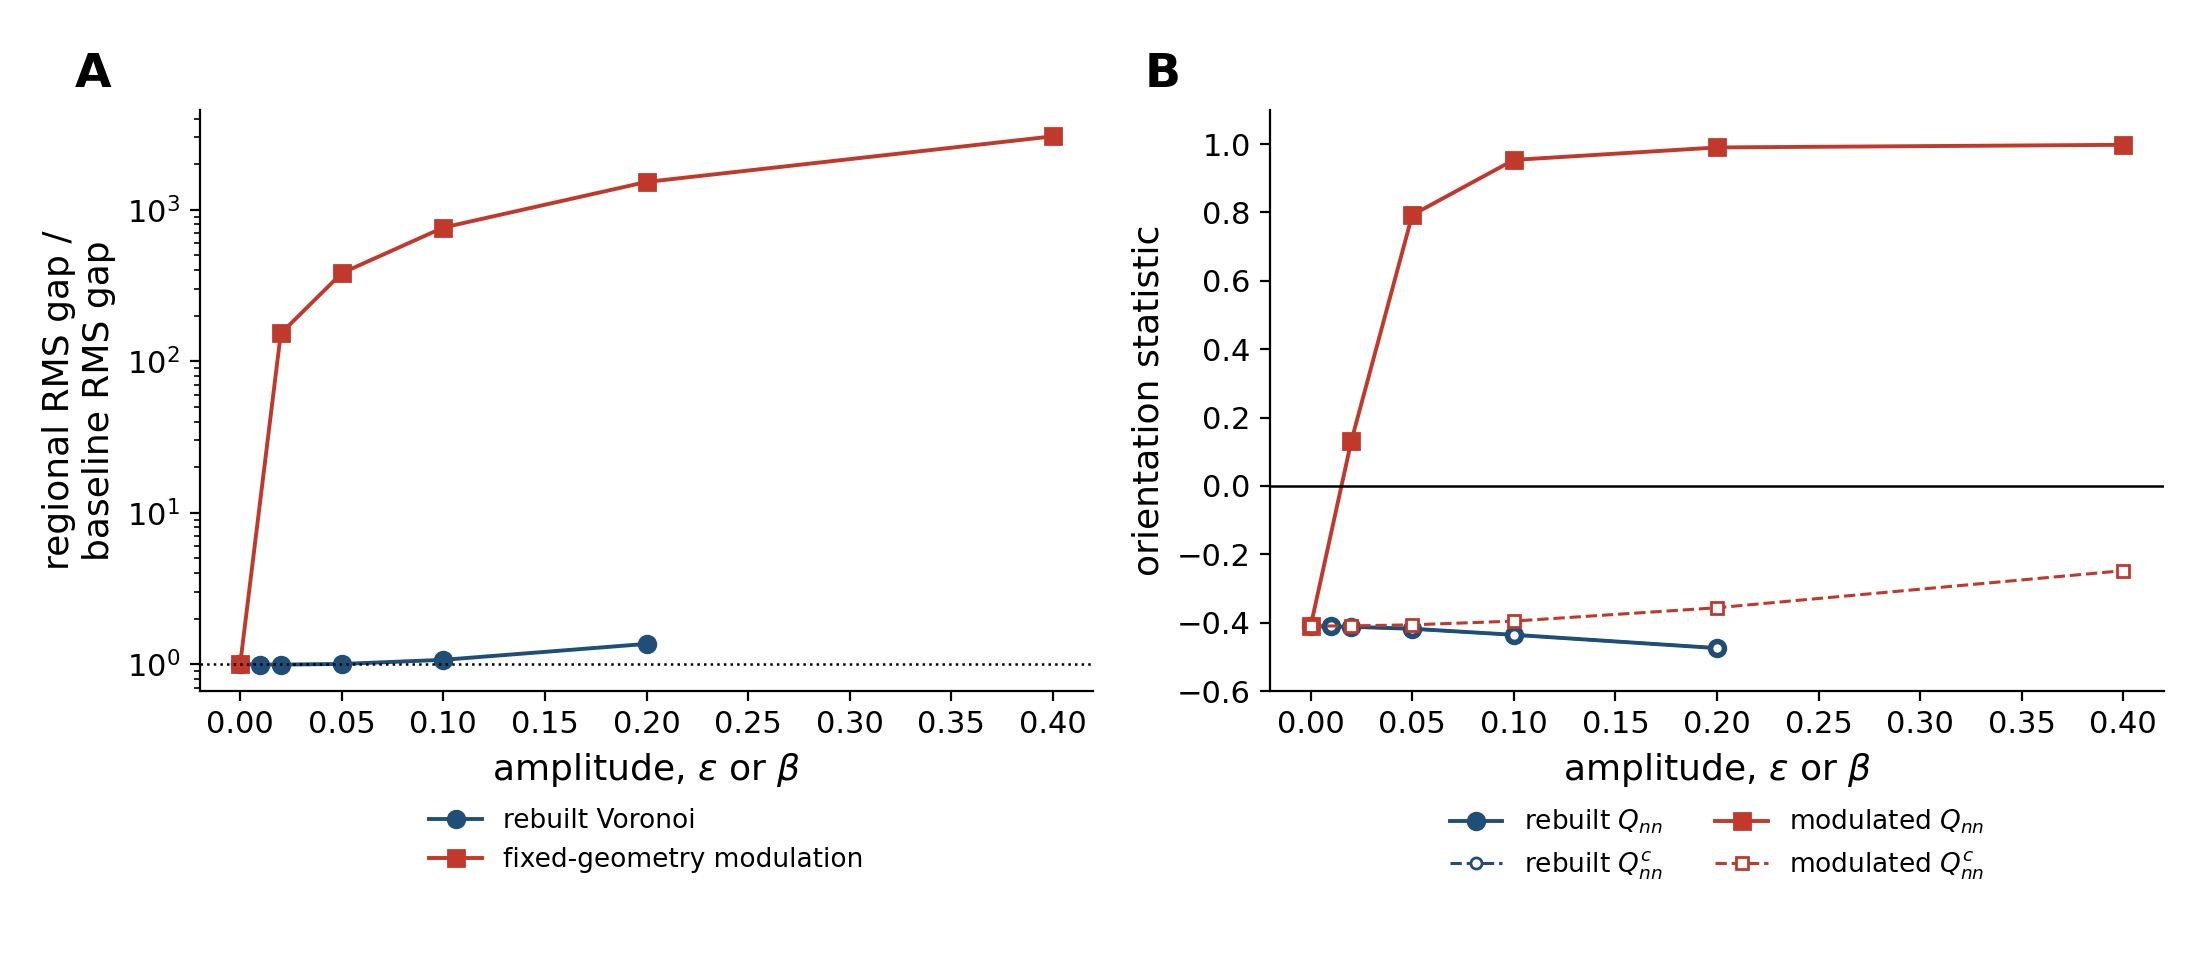

In [11]:
run_script('fit_window_controls.py')
run_script('run_regional_mechanism_figure.py')
show('figure_regional_mechanism_A.png', 560, generated=True)
show('figure_regional_mechanism_BC.png', 880, generated=True)

## 7. Mechanically relaxed networks

This separate experiment solves force balance with T=cL, comparing coherent and
radially permuted **coefficients**, and varying the distance to the fixed boundary.
The permutation matches coefficient distributions before relaxation; final
lengths, tensions and stress magnitudes need not match. Localized responses depend
strongly on the outer constraint. These static controls do not establish an active
bulk morphogenetic mechanism.


{
  "metadata": {
    "model": "positive zero-rest-length central springs on fixed honeycomb connectivity",
    "mechanical_law": "T_e = c_e L_e",
    "baseline_c": 1.7320508075688772,
    "reference_generator_spacing": 2.0,
    "patch_axial_radius": 22,
    "patch_cells": 1519,
    "vertices": 3174,
    "edges": 4692,
    "fixed_vertices": 270,
    "free_vertices": 2904,
    "regions": {
      "inner": 37,
      "domain": 127,
      "core": 517,
      "exterior": 216
    },
    "beta_values": [
      0.0,
      0.1,
      0.25,
      0.5,
      0.75
    ],
    "activation_radius": 12.0,
    "activation_transition_width": 2.0,
    "preferred_axis_radians": 0.0,
    "permutation_ring_width": 2.0,
    "realizations": 40,
    "seed": 2026091107,
    "numpy_version": "2.3.5",
    "scipy_version": "1.17.0",
    "parameter_selection": "Exploratory probes at beta 0.1-1.0 and patch radii 14-48 informed selection; not preregistered.",
    "uncertainty": "Permuted controls: empirical 2.5-97.5 pe

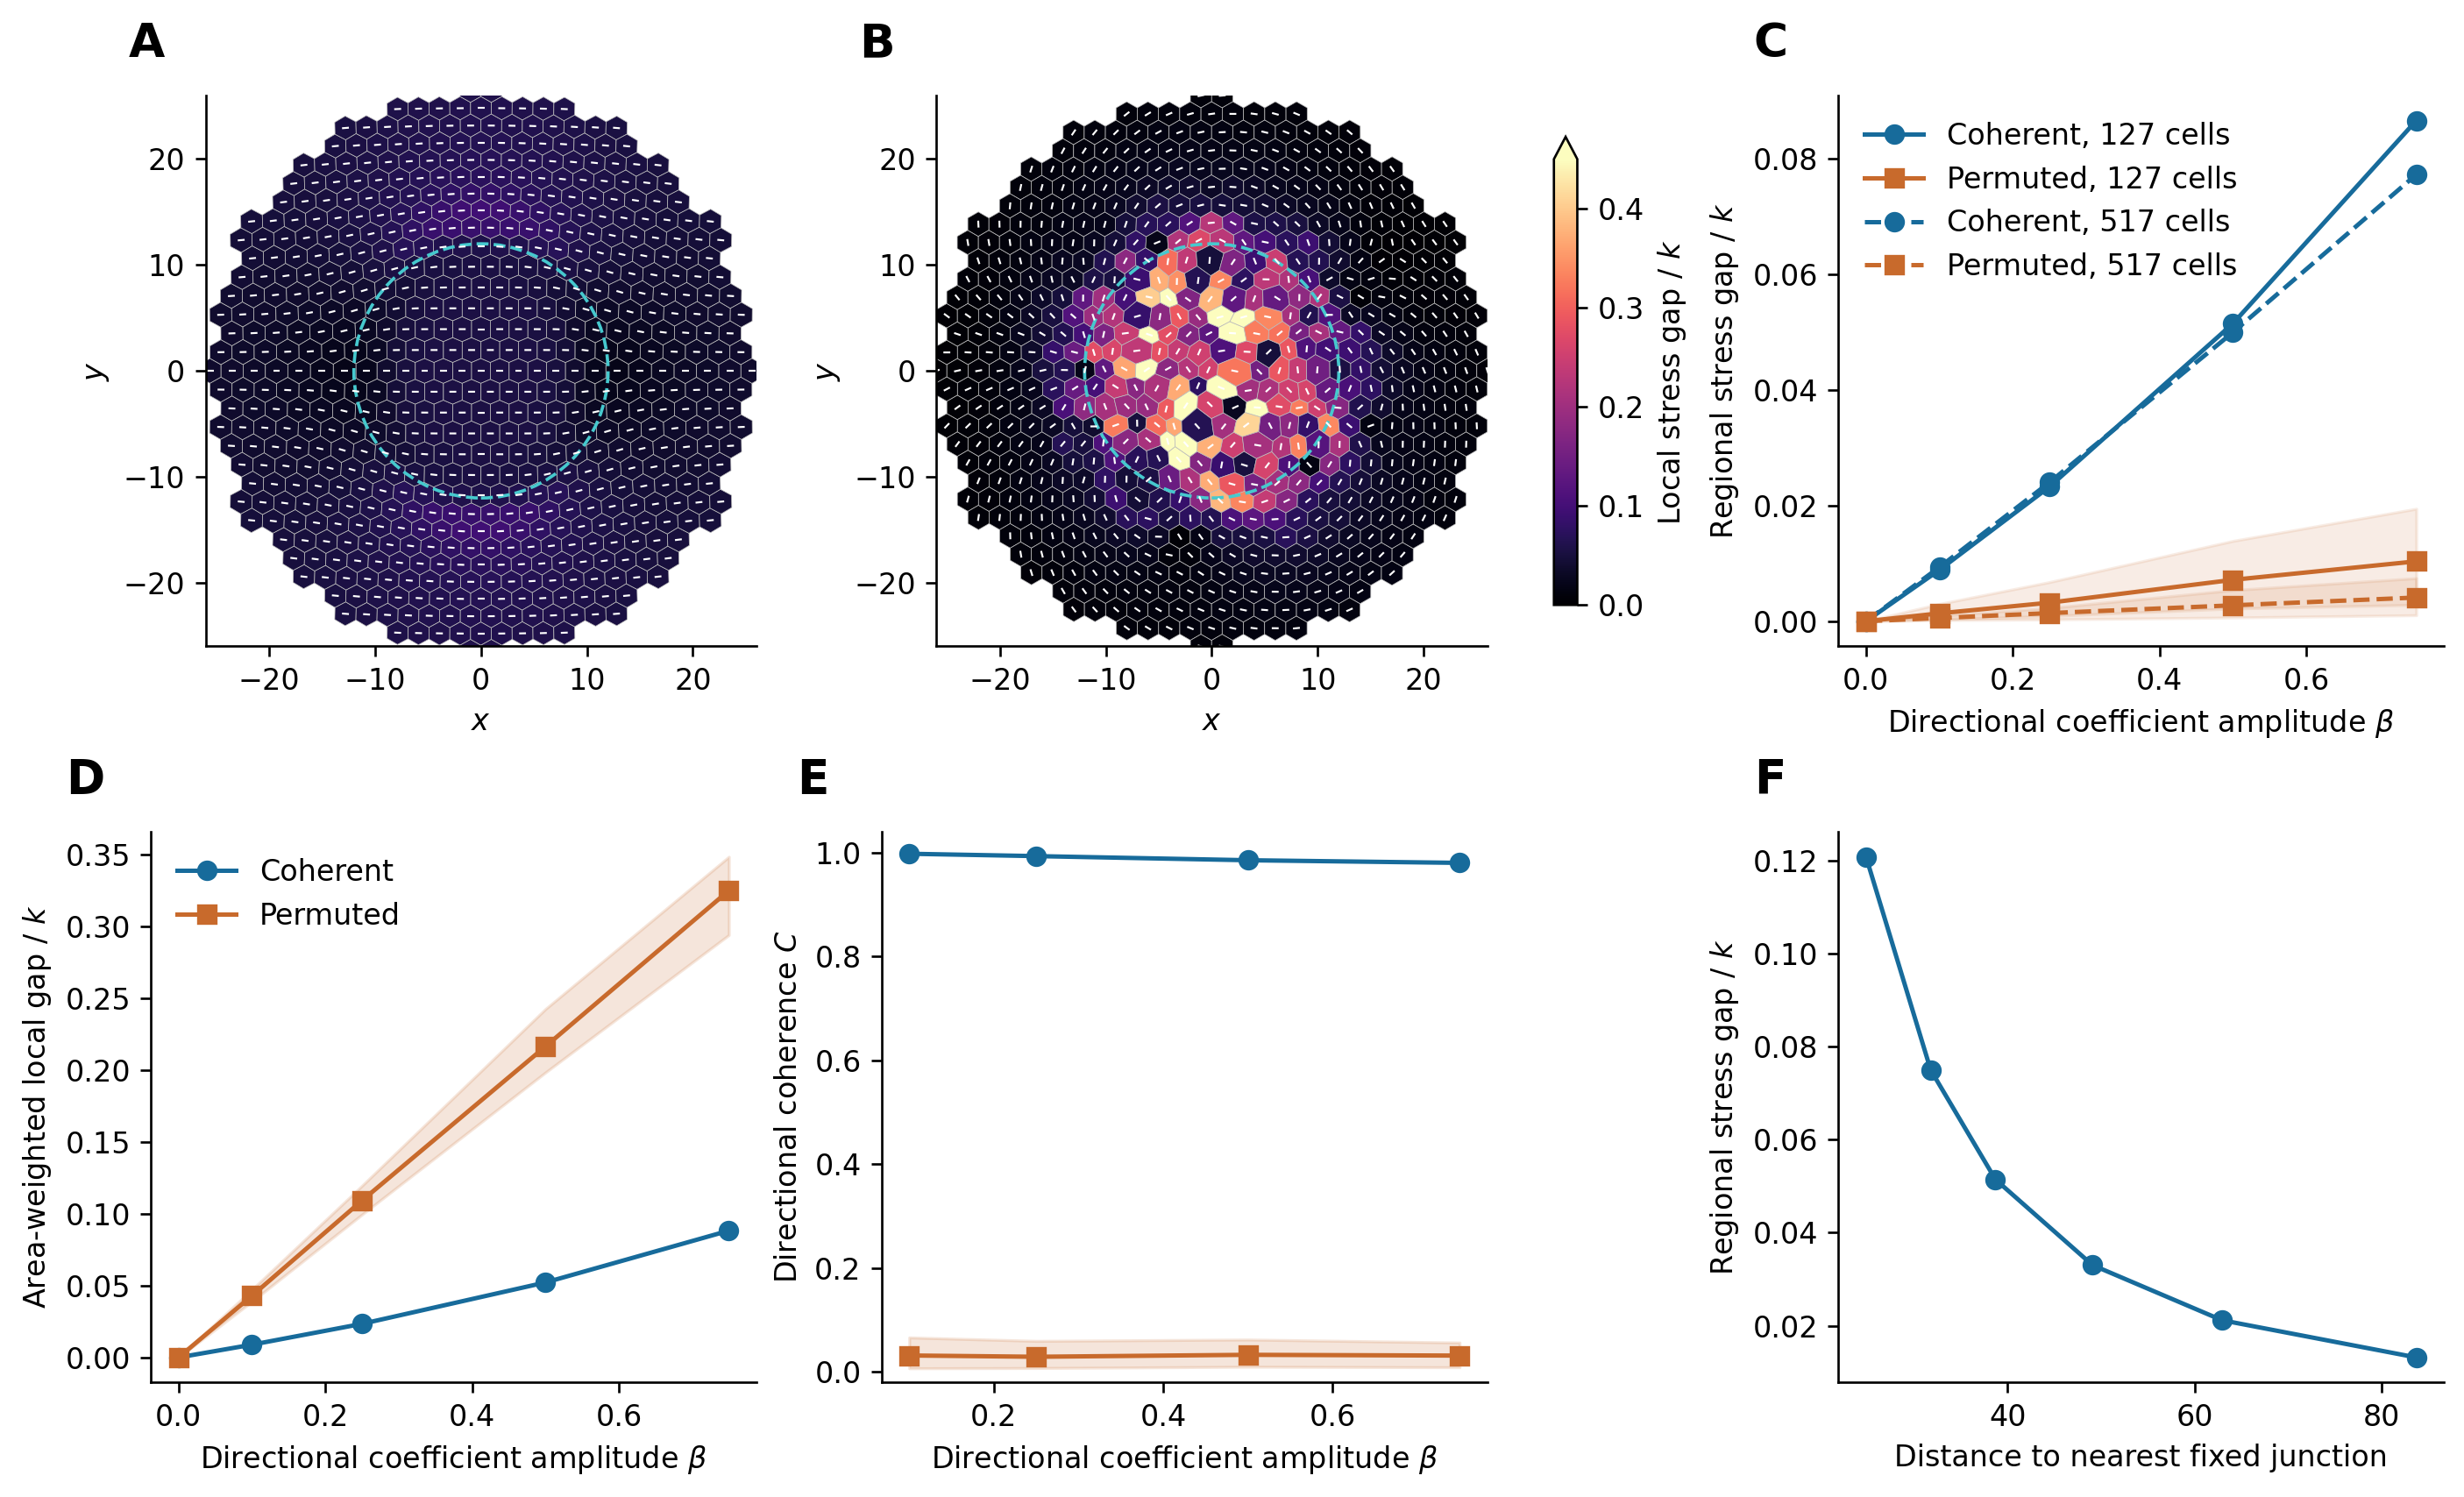

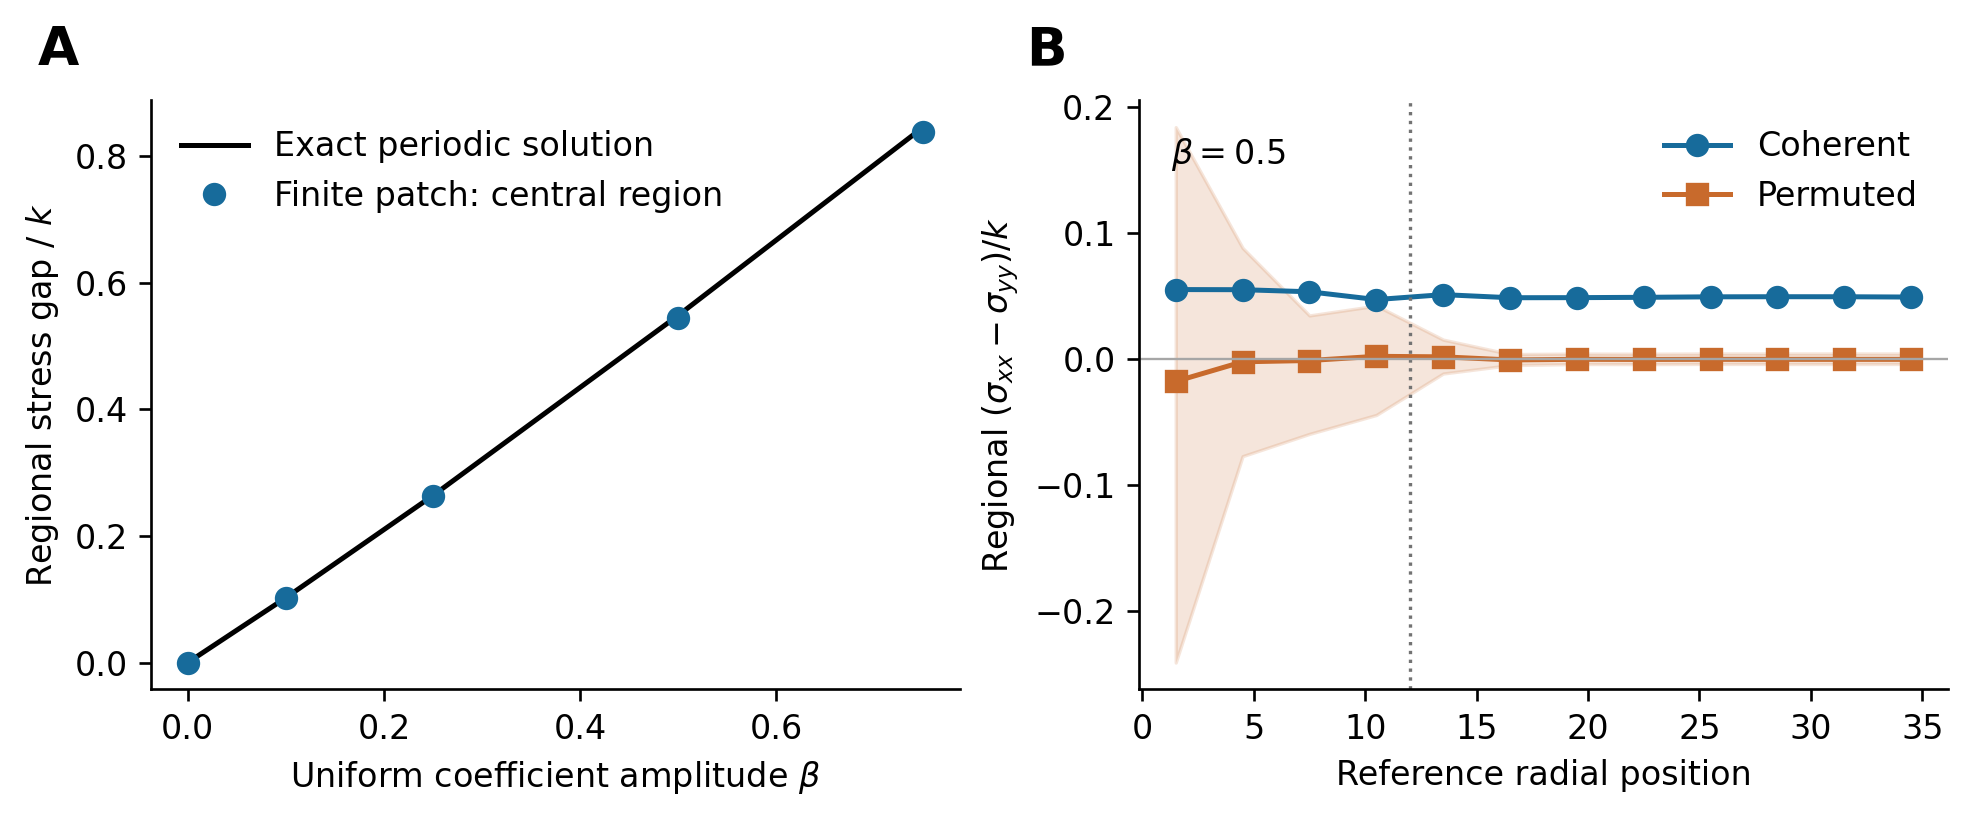

In [12]:
run_script('run_regional_mechanics.py')
show('regional_application.png', 880, generated=True)
show('regional_controls.png', 880, generated=True)

## 8. Independent verification

The verifiers use separate tensor assemblies and comparisons with raw records.
All plotted control aggregate points are checked against the exported realizations;
one full 324-cell window per loading amplitude is independently reconstructed.
Successful numerical checks do not establish biological validation or novelty.


In [13]:
run_script('verify_package.py')
run_script('verify_regional.py')
run_script('verify_window_controls.py')


Core derivations and tensor checks passed.
Original Figure 5–7 calculations and fitted statistics passed.
Tissue saved statistics and bootstrap intervals passed.
Saved data/package_verification.json

{
  "weighted_halfplane_identity": [
    {
      "weighted": false,
      "realization": 0,
      "cells": 25,
      "maximum_local_identity_error": 1.1379786002407855e-15,
      "regional_identity_error": 2.1073420786166253e-14,
      "regional_gap": 0.3833386129713574,
      "bound": 3.1386895646529718
    },
    {
      "weighted": false,
      "realization": 1,
      "cells": 25,
      "maximum_local_identity_error": 2.040034807748725e-15,
      "regional_identity_error": 3.6193270602780103e-14,
      "regional_gap": 0.17281077897028752,
      "bound": 3.655979160935486
    },
    {
      "weighted": false,
      "realization": 2,
      "cells": 25,
      "maximum_local_identity_error": 1.3877787807814457e-15,
      "regional_identity_error": 8.895661984809067e-15,
      "regional_gap"

## 9. Safe command-line workflow

From the complete extracted package directory:

```bash
python -m pip install -r requirements.txt
python code/run_all.py
python code/run_all.py --verify-only
```

Each command creates a new run under `reproduced/` and preserves source
`figures/` and `data/`. The default reruns regional/control experiments and verifies
supplied original numerical results. Internal scripts are workers: use this
wrapper or this notebook rather than invoking simulation scripts on the source tree.

Optional, potentially slow full historical resampling:

```bash
python code/run_all.py --regenerate-original --regenerate-tissue
```

This writes refreshed CSVs and tissue plots only in the isolated run.
Legacy cell plots use `reproduced_figures/` **within that run**, because their old
four-panel diagnostic layout differs from the submitted two-panel layout.
These optional expensive paths are not run by this notebook.

To compile the paper with its **original submitted figures**, separately run:

```bash
python code/build_documents.py
```

This requires `pdflatex`, `bibtex` and the standard packages loaded by the supplied
MDPI class (including `soul`). It updates `main.pdf` and `SI.pdf`, not figure assets.
No TeX installation is needed for the numerical notebook.

In [14]:
integrity = assert_source_unchanged(SOURCE_ROOT, SOURCE_HASHES, ROOT/'review/source_integrity.json')
print(json.dumps(integrity, indent=2))
print('All numerical outputs and verification reports:', ROOT)

{
  "source_figures_unchanged": true,
  "source_data_unchanged": true,
  "figure_assets_checked": 38,
  "data_files_checked": 44,
  "changed_paths": {
    "figures": [],
    "data": []
  }
}
All numerical outputs and verification reports: /workspace/scratch/d5d579d530b4/axioms_github_package/reproduced/notebook_20260916T010938Z_0stus7eg


## 10. Interpretation and reproducibility limits

* Fixed seeds are recorded in the data and source. Small floating-point differences
  can occur across numerical-library versions. Voronoi indexing changes can also
  alter seeded permutations; bitwise numerical equality across environments is
  not promised. Preservation of the submitted figure **files** is checked exactly.
* Historical figure asset names differ from manuscript figure numbers; see
  `README.md`. Regenerated controls may include corrected labels and additional
  mean-subtracted statistics. They are separate diagnostics, not replacements
  for the supplied publication figures.
* Signed distances are essential. Replacing them by absolute values changes
  the defined model and invalidates its general identities.
* Fixed-geometry tension modulation is not mechanically re-equilibrated. The
  mechanically relaxed experiment is a separate calculation. These controls do
  not establish biological validation or a new universal stress law.
* Public repository/DOI statements should only be made after the authors deposit
  and check the same version. Running this notebook requires the package, not a
  particular public URL.